# 🧪 ChemTastesDB - EDA


In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings

# Configure display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.4f}".format)

# Plot settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

warnings.filterwarnings('ignore')


## 1. Data Loading & Initial Inspection

Let's load the ChemTastesDB database and examine its basic structure.

In [ ]:
# Load the dataset
df_original = pd.read_excel("ChemTastesDB_database.xlsx")

print(f"\n Dataset Shape: {df_original.shape[0]:,} rows × {df_original.shape[1]} columns")
print(f"Memory Usage: {df_original.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("Features:")


# Display column info
for i, col in enumerate(df_original.columns, 1):
    dtype = df_original[col].dtype
    non_null = df_original[col].notna().sum()
    null_pct = (df_original[col].isna().sum() / len(df_original)) * 100
    unique = df_original[col].nunique()
    print(f"{i:2}. {col:<35} | Type: {str(dtype):<10} | Non-Null: {non_null:5} | Missing: {null_pct:5.2f}% | Unique: {unique:5}")

FileNotFoundError: [Errno 2] No such file or directory: 'filtered_db.csv'

In [4]:
# Display first and last few rows
print("FIRST 5 ")
display(df_original.head())

print("\nLAST 5 ")
display(df_original.tail())


FIRST 5 


,ID,Name,PubChem CID,CAS number,canonical SMILES,Taste,Class taste,Reference_(cod)/[pp]
0,0001,(-)-Haematoxylin,320930,517-28-2,Oc1cc2c(cc1O)C1c3ccc(c(c3OCC1(O)C2)O)O,Sweet,Sweetness,Arnoldi1995_((-)-1); Bassoli2001_(39)
1,0002,(+)-4β-hydroxyhernandulcin,126862,145385-64-4,CC(C)=CCCC(C)(O)C1CC(O)C(=CC1=O)C,Sweet,Sweetness,Ҫiçek2020_(32); Kinghorn1998_(2); Kinghorn2002...
2,0003,(+)-Dihydroquercetin 3-acetate,442540,78834-97-6,CC(=O)OC1C(Oc2cc(cc(c2C1=O)O)O)c1ccc(c(c1)O)O,Non-bitter; Sweet(6),Sweetness,Bouysset2020_(175); Ҫiçek2020_(19); Dagan-Wien...
3,0004,(+)-Dihydro-6-methoxy-luteolin 3-acetate,14886050,*,COc1c(cc2c(c1O)C(=O)C(OC(C)=O)C(O2)c1ccc(c(c1)...,Sweet,Sweetness,Ҫiçek2020_(21); Kinghorn2002_(28); Kinghorn201...
4,0005,(+)-Haematoxylin,442514,517-28-2,Oc1cc2c(cc1O)C1c3ccc(c(c3OCC1(O)C2)O)O,Sweet,Sweetness,Arnoldi1995_((+)-1); Arnoldi1996_(12); Bassoli...



LAST 5 


,ID,Name,PubChem CID,CAS number,canonical SMILES,Taste,Class taste,Reference_(cod)/[pp]
4073,4074,α-Hydroxy sanshool,53429684,83883-10-7,CC=CC=CC=CCCC=CC(=O)NCC(C)(C)O,"Heating, pungent, and tingling",Miscellaneous,Ley2012_[26]
4074,4075,γ-Linolenic acid,5280933,506-26-3,CCCCCC=CCC=CCC=CCCCCC(O)=O,Bitter/Burning/Pungent,Miscellaneous,Belitz2009_[164]
4075,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4076,NaN,"^ Chemical compound information (name, PubChem...",NaN,NaN,NaN,NaN,NaN,NaN
4077,NaN,* IUPAC name generated in Marvin Sketch versio...,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Data Quality Assessment

In [5]:
print("MISSING VALUES ANALYSIS")


# Calculate missing values
missing_df = pd.DataFrame({
    'Column': df_original.columns,
    'Missing Count': df_original.isnull().sum().values,
    'Missing %': (df_original.isnull().sum().values / len(df_original) * 100).round(2),
    'Non-Missing': df_original.notna().sum().values,
    'Data Type': df_original.dtypes.values
})
display(missing_df)

print("\nRows with missing values:")
missing_rows = df_original[df_original.isna().any(axis=1)]
print(f"Total rows with missing values: {len(missing_rows)}")
display(missing_rows)

MISSING VALUES ANALYSIS


,Column,Missing Count,Missing %,Non-Missing,Data Type
0,ID,3,0.0700,4075,object
1,Name,1,0.0200,4077,object
2,PubChem CID,3,0.0700,4075,object
3,CAS number,3,0.0700,4075,object
4,canonical SMILES,3,0.0700,4075,object
5,Taste,3,0.0700,4075,object
6,Class taste,3,0.0700,4075,object
7,Reference_(cod)/[pp],3,0.0700,4075,object



Rows with missing values:
Total rows with missing values: 3


,ID,Name,PubChem CID,CAS number,canonical SMILES,Taste,Class taste,Reference_(cod)/[pp]
4075,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4076,NaN,"^ Chemical compound information (name, PubChem...",NaN,NaN,NaN,NaN,NaN,NaN
4077,NaN,* IUPAC name generated in Marvin Sketch versio...,NaN,NaN,NaN,NaN,NaN,NaN


Data Cleaning

In [6]:
df = df_original.copy()

initial = len(df)
df = df.dropna(how='any')

print(f"\nFinal cleaned dataset shape: {df.shape}")
print(f"📊 Rows retained: {len(df):,} ")


Final cleaned dataset shape: (4075, 8)
📊 Rows retained: 4,075 


In [7]:
# df[df.isna().any(axis=1)]
len(df), df.shape 
df.columns


Index(['ID', 'Name', 'PubChem CID', 'CAS number', 'canonical SMILES', 'Taste',
       'Class taste', 'Reference_(cod)/[pp]'],
      dtype='object')

In [8]:
# 2.3 Duplicate Analysis
name_dupes = df['Name'].duplicated().sum()
print(f"Duplicate compound Names: {name_dupes}")

# Check for duplicates by SMILES
smiles_dupes = df['canonical SMILES'].duplicated().sum()
print(f"Duplicate SMILES strings: {smiles_dupes}")

smiles_counts = df['canonical SMILES'].value_counts()
duplicated_smiles = smiles_counts[smiles_counts > 1].head(5).index
print("SMILES that have duplicatted entries:", duplicated_smiles.shape[0])

# for smi in duplicated_smiles:
#     print(f"\n--- SMILES: {smi[:50]}... ---")
#     print("Number of entries:", smiles_counts[smi])
#     display(df[df['canonical SMILES'] == smi][['Name', 'Taste', 'Class taste']])


print("DUPLICATION SUMMARY (BY CANONICAL SMILES)")


smiles_counts = df['canonical SMILES'].value_counts()
duplicate_smiles_counts = smiles_counts[smiles_counts > 1]

print("Total molecules in dataset:", smiles_counts.shape[0])
print("Molecules with duplicates:", duplicate_smiles_counts.shape[0])
print("Total rows involved in duplication:", duplicate_smiles_counts.sum())

print("\nDuplicate count distribution:")
print(duplicate_smiles_counts.value_counts().sort_index())


Duplicate compound Names: 0
Duplicate SMILES strings: 226
SMILES that have duplicatted entries: 5
DUPLICATION SUMMARY (BY CANONICAL SMILES)
Total molecules in dataset: 3849
Molecules with duplicates: 193
Total rows involved in duplication: 419

Duplicate count distribution:
count
2    170
3     17
4      4
5      1
7      1
Name: count, dtype: int64


In [9]:
print(df["Taste"].unique())

['Sweet' 'Non-bitter; Sweet(6)' 'Non-bitter; Sweet' 'Sweetish'
 'Low sweet; Sweet' 'Sweet(8); Intensely sweet' 'Sweet; Less sweet'
 'Slightly sweet' 'Sweet(6); Sweet/Bitter' 'Sweet; Very sweet'
 'Tasteless; Sweet(2)' 'Sweet ' 'Sweet(2); Non-bitter'
 'Sweet(3); Non-bitter' 'Sweet(5); Non-bitter' 'Tasteless; Sweet(3)'
 'Sweet(4); Intensely sweet(2)' 'Sweet(2); Less sweet'
 'Slightly sweet; Sweet(2)' 'Very sweet; Sweet' 'Non-bitter; Sweet(3)'
 'Intensely sweet' 'Very sweet; Sweet(3)' 'Non-bitter; Sweet(5)'
 'Sweet(3); Sweetish' 'Sweet(5); Bitter'
 'Sweet(17); Bitter; Sweet/Bitter; Sweet (bitter aftertaste)'
 'Sweet(11); Bitter' 'Intensely sweet; Sweet(4)' 'Sweet(35); Sweet/Bitter'
 'Sweet; Non-bitter' 'Sweet(6); Non-bitter' 'Sweet; Sweet/Bitter'
 'Sweet(8); Non-bitter' 'Sweet(11); Non-bitter' 'Sulphurous/Sweet; Sweet'
 'Sweet(12); Non-bitter' 'Sweet(6); Bitter' 'Non-bitter; Sweet(7)'
 'Sweet(2); Sweet/Bitter' 'Sweet(4); Non-bitter' 'Sweet/Bitter; Sweet(2)'
 'Sweet(3); Sweet/Astringent; Sw

In [10]:
for desc in df["Taste"].unique():
    if ("sweet" in desc.lower()):
        print(desc)

Sweet
Non-bitter; Sweet(6)
Non-bitter; Sweet
Sweetish
Low sweet; Sweet
Sweet(8); Intensely sweet
Sweet; Less sweet
Slightly sweet
Sweet(6); Sweet/Bitter
Sweet; Very sweet
Tasteless; Sweet(2)
Sweet 
Sweet(2); Non-bitter
Sweet(3); Non-bitter
Sweet(5); Non-bitter
Tasteless; Sweet(3)
Sweet(4); Intensely sweet(2)
Sweet(2); Less sweet
Slightly sweet; Sweet(2)
Very sweet; Sweet
Non-bitter; Sweet(3)
Intensely sweet
Very sweet; Sweet(3)
Non-bitter; Sweet(5)
Sweet(3); Sweetish
Sweet(5); Bitter
Sweet(17); Bitter; Sweet/Bitter; Sweet (bitter aftertaste)
Sweet(11); Bitter
Intensely sweet; Sweet(4)
Sweet(35); Sweet/Bitter
Sweet; Non-bitter
Sweet(6); Non-bitter
Sweet; Sweet/Bitter
Sweet(8); Non-bitter
Sweet(11); Non-bitter
Sulphurous/Sweet; Sweet
Sweet(12); Non-bitter
Sweet(6); Bitter
Non-bitter; Sweet(7)
Sweet(2); Sweet/Bitter
Sweet(4); Non-bitter
Sweet/Bitter; Sweet(2)
Sweet(3); Sweet/Astringent; Sweet/Bitter; Non-bitter
Sweet(8); Non-sweet
Non-bitter; Sweet(2)
Non-bitter; Sweet(17)
Sweet(17); Non-

# semi manually, taste description was mapped to Taste classes
For example - Neutral; Sweet/Bitter to Sweet and Bitter both

In [11]:
## 3. Univariate Analysis

### 3.1 Target Variable Analysis - Class Taste Distribution

In [12]:
# TASTE_KEYWORDS = {
#     "Sweet":  ["sweet"],
#     "Bitter": ["bitter"],
#     "Umami":  ["umami", "msg", "brothy", "kokumi"],
#     "Sour":   ["sour"],
#     "Salty":  ["salty"]
# }

# # =========================================================
# # 3. MAP A SINGLE TASTE STRING → MULTI-LABEL VECTOR
# # =========================================================
# def map_tastes(taste_text):
#     """
#     Convert raw Taste description into binary labels:
#     Sweet, Bitter, Umami, Sour, Salty
#     """
#     # Handle missing safely
#     if pd.isna(taste_text):
#         return pd.Series({
#             "Sweet": 0,
#             "Bitter": 0,
#             "Umami": 0,
#             "Sour": 0,
#             "Salty": 0
#         })

#     text = taste_text.lower()

#     labels = {}
#     for taste, keywords in TASTE_KEYWORDS.items():
#         labels[taste] = int(
#             any(keyword in text for keyword in keywords)
#         )

#     return pd.Series(labels)

# # =========================================================
# # 4. APPLY MAPPING TO EACH ROW (ROW-LEVEL LABELS)
# # =========================================================
# taste_labels = df["Taste"].apply(map_tastes)

# df_labeled = pd.concat([df, taste_labels], axis=1)

# print("\nTaste mapping completed.")
# print(df_labeled[["Taste", "Sweet", "Bitter", "Umami", "Sour", "Salty"]].head())

# # =========================================================
# # 5. AGGREGATE DUPLICATES BY CANONICAL SMILES (LOGICAL OR)
# # =========================================================
# # If ANY duplicate row has a taste → molecule has that taste
# df_smiles_level = (
#     df_labeled
#     .groupby("canonical SMILES")[["Sweet", "Bitter", "Umami", "Sour", "Salty"]]
#     .max()
#     .reset_index()
# )

# # Attach a representative name (first occurrence)
# name_map = (
#     df.groupby("canonical SMILES")["Name"]
#     .first()
#     .reset_index()
# )

# df_final = df_smiles_level.merge(
#     name_map, on="canonical SMILES", how="left"
# )

# print("\nDuplicate aggregation completed.")
# print("Final molecule-level rows:", df_final.shape[0])

# # =========================================================
# # 6. SANITY CHECKS (IMPORTANT)
# # =========================================================
# # Number of tastes per molecule
# df_final["num_tastes"] = df_final[
#     ["Sweet", "Bitter", "Umami", "Sour", "Salty"]
# ].sum(axis=1)

# print("\nNumber of tastes per molecule:")
# print(df_final["num_tastes"].value_counts().sort_index())

# # Check molecules with multiple tastes
# print("\nExamples of multi-taste molecules:")
# print(df_final[df_final["num_tastes"] >= 2].head(10))

# # Verify umami detection
# print("\nSample Umami molecules:")
# print(df_final[df_final["Umami"] == 1].head(10))

# # =========================================================
# # 7. SAVE FINAL CLEAN DATASET
# # =========================================================
# OUTPUT_PATH = "chemtastesdb_multilabel_clean.csv"
# df_final.to_csv(OUTPUT_PATH, index=False)

# print(f"\nFinal multi-label dataset saved to: {OUTPUT_PATH}")

df_final = pd.read_csv("chemtastesdb_multilabel_clean.csv")

---

# Part 2: Embedding Analysis

This section provides detailed exploratory data analysis on the molecular embeddings generated from the ChemTastesDB dataset:

1. **Mol2Vec Embeddings** (300 dimensions) - Word2Vec-style learned representations
2. **RDKit 2D Descriptors** (~200 features) - Physicochemical and structural properties
3. **Morgan Fingerprints** (2048 bits) - Circular topological fingerprints
4. **MACCS Keys** (167 bits) - Structural key fingerprints
5. **ChemBERTa Embeddings** (768 dimensions) - Transformer-based representations


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import warnings
from sklearn.impute import SimpleImputer

warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
EMBEDDINGS_DIR = "Embeddings/"



# Mol2Vec (300 dims)
mol2vec_df = pd.read_csv(f"{EMBEDDINGS_DIR}chemtastes_mol2vec.csv")
mol2vec_cols = [c for c in mol2vec_df.columns if c.startswith('mol2vec_')]
print(f"\n✓ Mol2Vec: {mol2vec_df.shape[0]} samples, {len(mol2vec_cols)} dimensions")

# RDKit Descriptors (~200 features)
rdkit_df = pd.read_csv(f"{EMBEDDINGS_DIR}chemtastes_rdkit_descriptors.csv")
rdkit_cols = [c for c in rdkit_df.columns if c not in ['Sweet', 'Bitter', 'Umami', 'Sour', 'Salty']]
print(f"✓ RDKit Descriptors: {rdkit_df.shape[0]} samples, {len(rdkit_cols)} features")

# Morgan Fingerprints (2048 bits)
morgan_df = pd.read_csv("./Embeddings/chemtastes_morgan_fps.csv")
morgan_cols = [c for c in morgan_df.columns if c.startswith('fp_bit_')]
print(f"✓ Morgan Fingerprints: {morgan_df.shape[0]} samples, {len(morgan_cols)} bits")

# MACCS Keys (167 bits)
maccs_df = pd.read_csv(f"{EMBEDDINGS_DIR}chemtastes_maccs.csv")
maccs_cols = [c for c in maccs_df.columns if c.startswith('maccs_')]
print(f"✓ MACCS Keys: {maccs_df.shape[0]} samples, {len(maccs_cols)} bits")

# ChemBERTa (768 dims)
chemberta_df = pd.read_csv(f"{EMBEDDINGS_DIR}chemtastes_chemberta.csv")
chemberta_cols = [c for c in chemberta_df.columns if c.startswith('chemberta_')]
print(f"✓ ChemBERTa: {chemberta_df.shape[0]} samples, {len(chemberta_cols)} dimensions")

# Define taste labels
taste_labels = ['Sweet', 'Bitter', 'Umami', 'Sour', 'Salty']

# Create embedding summary
embedding_summary = pd.DataFrame({
    'Embedding Type': ['Mol2Vec', 'RDKit Descriptors', 'Morgan FP', 'MACCS Keys', 'ChemBERTa'],
    'Dimensions': [len(mol2vec_cols), len(rdkit_cols), len(morgan_cols), len(maccs_cols), len(chemberta_cols)],
    'Data Type': ['Continuous', 'Continuous', 'Binary', 'Binary', 'Continuous'],
})


print("EMBEDDING SUMMARY")

print(embedding_summary.to_string(index=False))


✓ Mol2Vec: 3849 samples, 300 dimensions
✓ RDKit Descriptors: 3849 samples, 217 features
✓ Morgan Fingerprints: 3849 samples, 2048 bits
✓ MACCS Keys: 3849 samples, 167 bits
✓ ChemBERTa: 3849 samples, 768 dimensions
EMBEDDING SUMMARY
   Embedding Type  Dimensions  Data Type
          Mol2Vec         300 Continuous
RDKit Descriptors         217 Continuous
        Morgan FP        2048     Binary
       MACCS Keys         167     Binary
        ChemBERTa         768 Continuous


## 2.2 Embedding Data Quality Assessment

In [14]:
np.nanvar(mol2vec_df, axis=0)

array([0.23013431, 0.24812875, 0.07076909, 0.02678119, 0.01433755,
       0.00247551, 0.00404205, 0.00241121, 0.00557036, 0.00368191,
       0.00425357, 0.00183007, 0.00291359, 0.00972708, 0.00545109,
       0.0053499 , 0.00324956, 0.01325845, 0.00272067, 0.00664414,
       0.00377872, 0.00411918, 0.00863873, 0.00347825, 0.00240478,
       0.00314382, 0.00192677, 0.0039595 , 0.00315753, 0.00469914,
       0.00297891, 0.00448649, 0.00358983, 0.00248842, 0.00330916,
       0.0070238 , 0.00160345, 0.00282058, 0.00463849, 0.00314428,
       0.00307783, 0.00255954, 0.00322989, 0.00336607, 0.00377796,
       0.00243319, 0.00404182, 0.00227234, 0.003057  , 0.00594359,
       0.00339692, 0.00339821, 0.00799105, 0.00144536, 0.0023914 ,
       0.00470136, 0.00238756, 0.00365133, 0.00535587, 0.00572049,
       0.00529521, 0.00526898, 0.00525923, 0.00190898, 0.00204483,
       0.00396666, 0.004356  , 0.00437724, 0.00290572, 0.0032972 ,
       0.00347902, 0.00356938, 0.0024394 , 0.00646555, 0.00648

In [15]:
def analyze_embedding_quality(df, cols, name):
    X = df[cols].values
    
    # Missing values
    missing_total = np.isnan(X).sum()
    inf_total = np.isinf(X).sum()
    
    # Zero variance columns
    variances = np.nanvar(X, axis=0)
    zero_var_cols = np.sum(variances == 0)
    
    # Basic statistics
    stats_dict = {
        'Embedding': name,
        'Samples': X.shape[0],
        'Features': X.shape[1],
        'Missing Values': missing_total,
        'Inf Values': inf_total,
        'Zero-Var Features': zero_var_cols,
        'Min Value': f"{np.nanmin(X):.4f}",
        'Max Value': f"{np.nanmax(X):.4f}",
        'Mean': f"{np.nanmean(X):.4f}",
        'Std': f"{np.nanstd(X):.4f}"
    }
    
    return stats_dict

quality_results = []
quality_results.append(analyze_embedding_quality(mol2vec_df, mol2vec_cols, 'Mol2Vec'))
quality_results.append(analyze_embedding_quality(rdkit_df, rdkit_cols, 'RDKit'))
quality_results.append(analyze_embedding_quality(morgan_df, morgan_cols, 'Morgan FP'))
quality_results.append(analyze_embedding_quality(maccs_df, maccs_cols, 'MACCS'))
quality_results.append(analyze_embedding_quality(chemberta_df, chemberta_cols, 'ChemBERTa'))

quality_df = pd.DataFrame(quality_results)


print("EMBEDDING DATA QUALITY")

print(quality_df.to_string(index=False))


EMBEDDING DATA QUALITY
Embedding  Samples  Features  Missing Values  Inf Values  Zero-Var Features Min Value                                                                                                                   Max Value                                                                                                                  Mean                                                                                                                      Std
  Mol2Vec     3849       300               0           0                  0   -0.8664                                                                                                                      0.8392                                                                                                               -0.0034                                                                                                                   0.1258
    RDKit     3849       217            4940           0                  7  -7

In [16]:
print("RDKIT DATA CLEANING & PREPROCESSING")

# Columns with missing values
missing_cols = rdkit_df[rdkit_cols].columns[rdkit_df[rdkit_cols].isna().any()].tolist()
print(f"Columns with missing values: {len(missing_cols)}")
if missing_cols:
    print(f"  → {missing_cols[:5]}{'...' if len(missing_cols) > 5 else ''}")

# Columns with infinity values
inf_cols = [col for col in rdkit_cols if np.isinf(rdkit_df[col]).any()]
print(f"Columns with infinity values: {len(inf_cols)}")
if inf_cols:
    print(f"  → {inf_cols[:5]}{'...' if len(inf_cols) > 5 else ''}")

# Columns with extremely large values (> 1e10)
large_val_cols = [col for col in rdkit_cols if rdkit_df[col].abs().max() > 1e10]
print(f"Columns with extreme values (>1e10): {len(large_val_cols)}")
if large_val_cols:
    print(f"  → {large_val_cols[:5]}{'...' if len(large_val_cols) > 5 else ''}")

# Zero variance columns
zero_var_cols = [col for col in rdkit_cols if rdkit_df[col].std() == 0 or rdkit_df[col].isna().all()]
print(f"Zero variance columns: {len(zero_var_cols)}")
if zero_var_cols:
    print(f"  → {zero_var_cols}")

# 2. Create cleaned RDKit dataframe
print("\n2. CLEANING RDKIT DESCRIPTORS")
print("-" * 40)

rdkit_df_clean = rdkit_df.copy()

# Step 1: Remove zero-variance columns
cols_to_remove = set(zero_var_cols)
print(f"Removing {len(cols_to_remove)} zero-variance columns")

# Step 2: Remove columns with extreme values (often problematic descriptors)
cols_to_remove.update(large_val_cols)
print(f"Removing {len(large_val_cols)} columns with extreme values")

# Step 3: Remove columns with >10% missing values
high_missing_cols = [col for col in rdkit_cols if rdkit_df[col].isna().mean() > 0.10]
cols_to_remove.update(high_missing_cols)
print(f"Removing {len(high_missing_cols)} columns with >10% missing values")

# Get clean columns
rdkit_cols_clean = [col for col in rdkit_cols if col not in cols_to_remove]
print(f"\nOriginal columns: {len(rdkit_cols)}")
print(f"Columns after cleaning: {len(rdkit_cols_clean)}")
print(f"Columns removed: {len(cols_to_remove)}")

# Step 4: Handle remaining missing values with median imputation
print("\n3. IMPUTING REMAINING MISSING VALUES")
print("-" * 40)


# Check remaining missing values
remaining_missing = rdkit_df_clean[rdkit_cols_clean].isna().sum().sum()
print(f"Remaining missing values before imputation: {remaining_missing}")

if remaining_missing > 0:
    # Median imputation (robust to outliers)
    imputer = SimpleImputer(strategy='median')
    rdkit_df_clean[rdkit_cols_clean] = imputer.fit_transform(rdkit_df_clean[rdkit_cols_clean])
    print(f"Missing values after median imputation: {rdkit_df_clean[rdkit_cols_clean].isna().sum().sum()}")

# Step 5: Replace any remaining inf values
rdkit_df_clean[rdkit_cols_clean] = rdkit_df_clean[rdkit_cols_clean].replace([np.inf, -np.inf], np.nan)
rdkit_df_clean[rdkit_cols_clean] = rdkit_df_clean[rdkit_cols_clean].fillna(rdkit_df_clean[rdkit_cols_clean].median())

# 4. Verify cleaned data
print("\n4. VERIFICATION OF CLEANED DATA")
print("-" * 40)

rdkit_clean_stats = {
    'Samples': len(rdkit_df_clean),
    'Features': len(rdkit_cols_clean),
    'Missing Values': rdkit_df_clean[rdkit_cols_clean].isna().sum().sum(),
    'Inf Values': np.isinf(rdkit_df_clean[rdkit_cols_clean]).sum().sum(),
    'Min Value': rdkit_df_clean[rdkit_cols_clean].min().min(),
    'Max Value': rdkit_df_clean[rdkit_cols_clean].max().max(),
    'Mean': rdkit_df_clean[rdkit_cols_clean].values.mean(),
    'Std': rdkit_df_clean[rdkit_cols_clean].values.std()
}

for key, value in rdkit_clean_stats.items():
    if isinstance(value, float):
        print(f"  {key}: {value:.4f}")
    else:
        print(f"  {key}: {value}")

# 5. Save cleaned version (optional)
print("\n5. SUMMARY")
print("-" * 40)
print(f"✓ Cleaned RDKit descriptors ready for analysis")
print(f"✓ {len(rdkit_cols_clean)} features retained out of {len(rdkit_cols)}")
print(f"✓ All values now in reasonable range: [{rdkit_clean_stats['Min Value']:.2f}, {rdkit_clean_stats['Max Value']:.2f}]")

# Update rdkit_cols to use clean version for subsequent analysis
rdkit_cols_original = rdkit_cols.copy()
rdkit_cols = rdkit_cols_clean
rdkit_df = rdkit_df_clean

# Display removed columns for reference
print("\n📋 REMOVED COLUMNS:")
for col in sorted(cols_to_remove):
    reason = []
    if col in zero_var_cols:
        reason.append("zero-var")
    if col in large_val_cols:
        reason.append("extreme-values")
    if col in high_missing_cols:
        reason.append("high-missing")
    print(f"  - {col}: {', '.join(reason)}")

RDKIT DATA CLEANING & PREPROCESSING
Columns with missing values: 12
  → ['MaxPartialCharge', 'MinPartialCharge', 'MaxAbsPartialCharge', 'MinAbsPartialCharge', 'BCUT2D_MWHI']...
Columns with infinity values: 0
Columns with extreme values (>1e10): 1
  → ['Ipc']
Zero variance columns: 7
  → ['SMR_VSA8', 'SlogP_VSA9', 'fr_azide', 'fr_diazo', 'fr_nitroso', 'fr_oxazole', 'fr_prisulfonamd']

2. CLEANING RDKIT DESCRIPTORS
----------------------------------------
Removing 7 zero-variance columns
Removing 1 columns with extreme values
Removing 8 columns with >10% missing values

Original columns: 217
Columns after cleaning: 201
Columns removed: 16

3. IMPUTING REMAINING MISSING VALUES
----------------------------------------
Remaining missing values before imputation: 12
Missing values after median imputation: 0

4. VERIFICATION OF CLEANED DATA
----------------------------------------
  Samples: 3849
  Features: 201
  Missing Values: 0
  Inf Values: 0
  Min Value: -70.2417
  Max Value: 11289.325

In [17]:

def analyze_embedding_quality(df, cols, name):
    """Comprehensive quality analysis for an embedding"""
    X = df[cols].values
    
    # Missing values
    missing_total = np.isnan(X).sum()
    missing_pct = (missing_total / X.size) * 100
    
    # Infinity values
    inf_total = np.isinf(X).sum()
    inf_pct = (inf_total / X.size) * 100
    
    # Zero variance columns
    variances = np.nanvar(X, axis=0)
    zero_var_cols = np.sum(variances == 0)
    
    # Basic statistics
    stats_dict = {
        'Embedding': name,
        'Samples': X.shape[0],
        'Features': X.shape[1],
        'Missing Values': missing_total,
        'Missing %': f"{missing_pct:.4f}%",
        'Inf Values': inf_total,
        'Zero-Var Features': zero_var_cols,
        'Min Value': f"{np.nanmin(X):.4f}",
        'Max Value': f"{np.nanmax(X):.4f}",
        'Mean': f"{np.nanmean(X):.4f}",
        'Std': f"{np.nanstd(X):.4f}"
    }
    
    return stats_dict

# Analyze all embeddings
quality_results = []
quality_results.append(analyze_embedding_quality(mol2vec_df, mol2vec_cols, 'Mol2Vec'))
quality_results.append(analyze_embedding_quality(rdkit_df, rdkit_cols, 'RDKit'))
quality_results.append(analyze_embedding_quality(morgan_df, morgan_cols, 'Morgan FP'))
quality_results.append(analyze_embedding_quality(maccs_df, maccs_cols, 'MACCS'))
quality_results.append(analyze_embedding_quality(chemberta_df, chemberta_cols, 'ChemBERTa'))

quality_df = pd.DataFrame(quality_results)


print("EMBEDDING DATA QUALITY ASSESSMENT")

print(quality_df.to_string(index=False))

# Check for RDKit specific issues (often has inf values)
rdkit_inf_cols = []
for col in rdkit_cols:
    if np.isinf(rdkit_df[col]).any():
        rdkit_inf_cols.append(col)

if rdkit_inf_cols:
    print(f"\n⚠️  RDKit columns with infinity values: {len(rdkit_inf_cols)}")
    print(f"   Columns: {rdkit_inf_cols[:10]}{'...' if len(rdkit_inf_cols) > 10 else ''}")

EMBEDDING DATA QUALITY ASSESSMENT
Embedding  Samples  Features  Missing Values Missing %  Inf Values  Zero-Var Features Min Value  Max Value    Mean     Std
  Mol2Vec     3849       300               0   0.0000%           0                  0   -0.8664     0.8392 -0.0034  0.1258
    RDKit     3849       201               0   0.0000%           0                  0  -70.2417 11289.3252 15.9988 85.8279
Morgan FP     3849      2048               0   0.0000%           0                 10    0.0000     1.0000  0.0189  0.1362
    MACCS     3849       167               0   0.0000%           0                  8    0.0000     1.0000  0.2444  0.4297
ChemBERTa     3849       768               0   0.0000%           0                  0   -5.5814     5.7877  0.0000  1.0003


## 2.3 Continuous Embedding Analysis (Mol2Vec, RDKit, ChemBERTa)

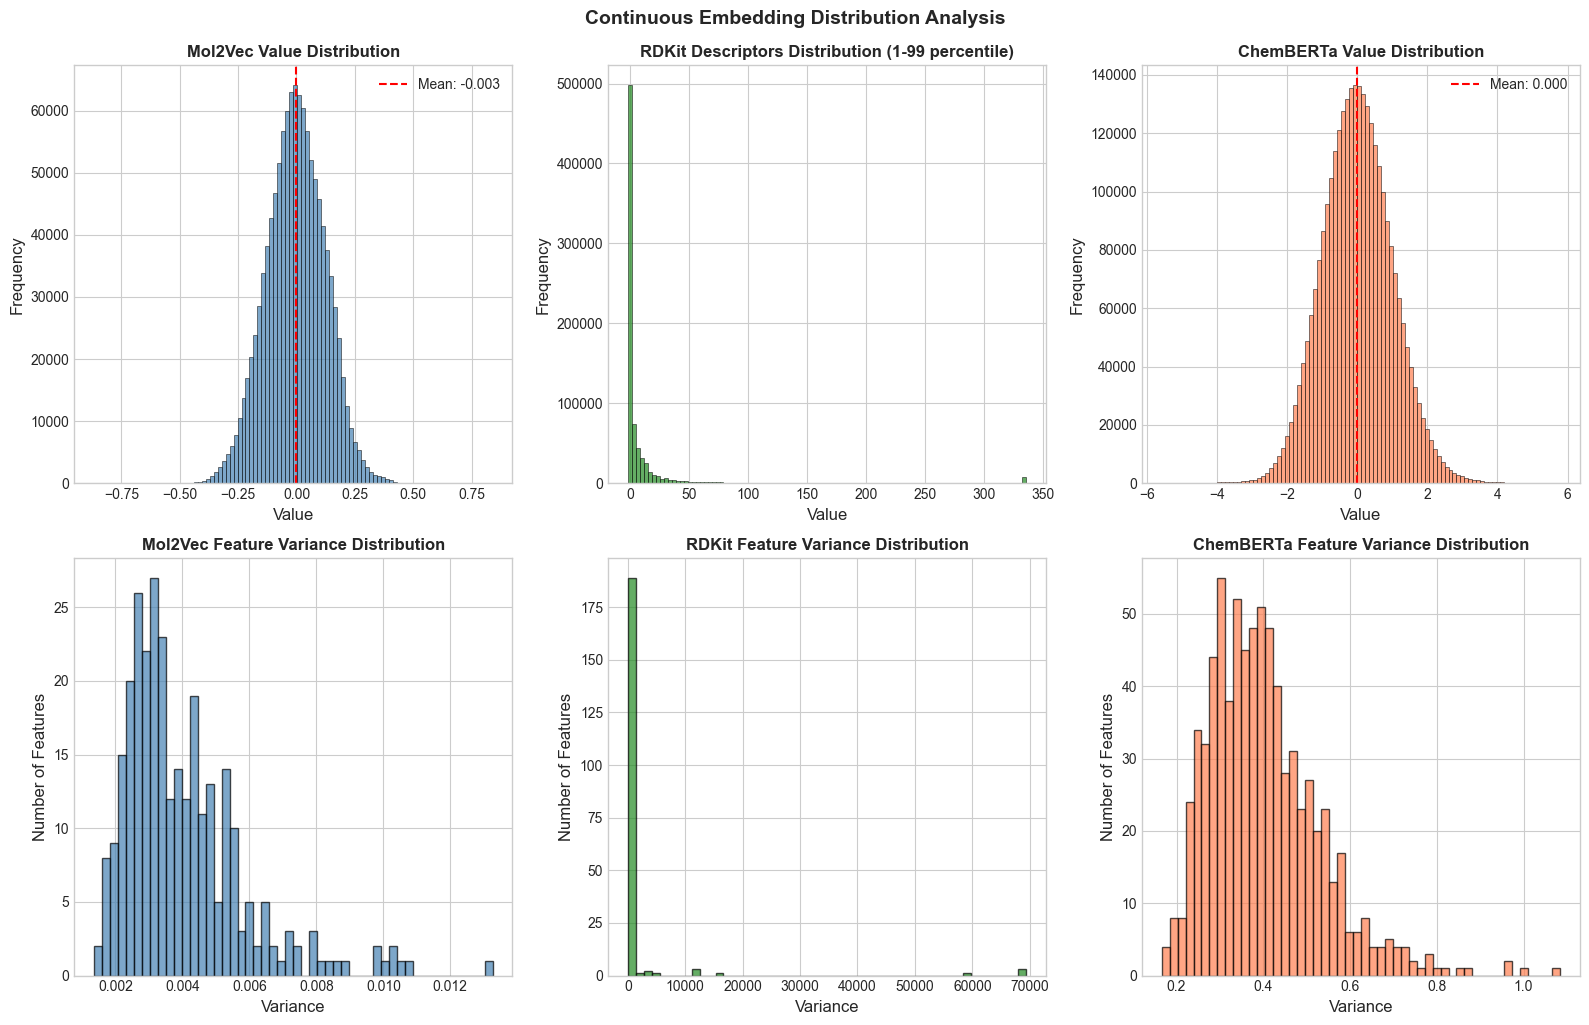

CONTINUOUS EMBEDDING STATISTICS

Mol2Vec:
  Range: [-0.8664, 0.8392]
  Mean: -0.0034, Std: 0.1258
  Skewness: -0.0389
  Kurtosis: 0.0507

ChemBERTa:
  Range: [-5.5814, 5.7877]
  Mean: 0.0000, Std: 1.0003
  Skewness: 0.1394
  Kurtosis: 0.3449


In [18]:
# ============================================================
# 2.3.1 Distribution Analysis for Continuous Embeddings
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Mol2Vec distribution
ax1 = axes[0, 0]
mol2vec_flat = mol2vec_df[mol2vec_cols].values.flatten()
ax1.hist(mol2vec_flat, bins=100, alpha=0.7, color='steelblue', edgecolor='black', linewidth=0.5)
ax1.set_title('Mol2Vec Value Distribution', fontsize=12, fontweight='bold')
ax1.set_xlabel('Value')
ax1.set_ylabel('Frequency')
ax1.axvline(np.mean(mol2vec_flat), color='red', linestyle='--', label=f'Mean: {np.mean(mol2vec_flat):.3f}')
ax1.legend()

# RDKit distribution (clipped for visualization)
ax2 = axes[0, 1]
rdkit_flat = rdkit_df[rdkit_cols].replace([np.inf, -np.inf], np.nan).values.flatten()
rdkit_flat = rdkit_flat[~np.isnan(rdkit_flat)]
rdkit_clipped = np.clip(rdkit_flat, np.percentile(rdkit_flat, 1), np.percentile(rdkit_flat, 99))
ax2.hist(rdkit_clipped, bins=100, alpha=0.7, color='forestgreen', edgecolor='black', linewidth=0.5)
ax2.set_title('RDKit Descriptors Distribution (1-99 percentile)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Value')
ax2.set_ylabel('Frequency')

# ChemBERTa distribution
ax3 = axes[0, 2]
chemberta_flat = chemberta_df[chemberta_cols].values.flatten()
ax3.hist(chemberta_flat, bins=100, alpha=0.7, color='coral', edgecolor='black', linewidth=0.5)
ax3.set_title('ChemBERTa Value Distribution', fontsize=12, fontweight='bold')
ax3.set_xlabel('Value')
ax3.set_ylabel('Frequency')
ax3.axvline(np.mean(chemberta_flat), color='red', linestyle='--', label=f'Mean: {np.mean(chemberta_flat):.3f}')
ax3.legend()

# Variance distribution for each embedding
ax4 = axes[1, 0]
mol2vec_var = mol2vec_df[mol2vec_cols].var()
ax4.hist(mol2vec_var, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
ax4.set_title('Mol2Vec Feature Variance Distribution', fontsize=12, fontweight='bold')
ax4.set_xlabel('Variance')
ax4.set_ylabel('Number of Features')

ax5 = axes[1, 1]
rdkit_var = rdkit_df[rdkit_cols].replace([np.inf, -np.inf], np.nan).var()
rdkit_var_clipped = np.clip(rdkit_var, 0, np.percentile(rdkit_var.dropna(), 99))
ax5.hist(rdkit_var_clipped, bins=50, alpha=0.7, color='forestgreen', edgecolor='black')
ax5.set_title('RDKit Feature Variance Distribution', fontsize=12, fontweight='bold')
ax5.set_xlabel('Variance')
ax5.set_ylabel('Number of Features')

ax6 = axes[1, 2]
chemberta_var = chemberta_df[chemberta_cols].var()
ax6.hist(chemberta_var, bins=50, alpha=0.7, color='coral', edgecolor='black')
ax6.set_title('ChemBERTa Feature Variance Distribution', fontsize=12, fontweight='bold')
ax6.set_xlabel('Variance')
ax6.set_ylabel('Number of Features')

plt.tight_layout()
plt.suptitle('Continuous Embedding Distribution Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.show()

# Print statistics

print("CONTINUOUS EMBEDDING STATISTICS")

for name, flat in [('Mol2Vec', mol2vec_flat), ('ChemBERTa', chemberta_flat)]:
    print(f"\n{name}:")
    print(f"  Range: [{np.min(flat):.4f}, {np.max(flat):.4f}]")
    print(f"  Mean: {np.mean(flat):.4f}, Std: {np.std(flat):.4f}")
    print(f"  Skewness: {stats.skew(flat):.4f}")
    print(f"  Kurtosis: {stats.kurtosis(flat):.4f}")

## 2.4 Binary Fingerprint Analysis (Morgan FP, MACCS Keys)

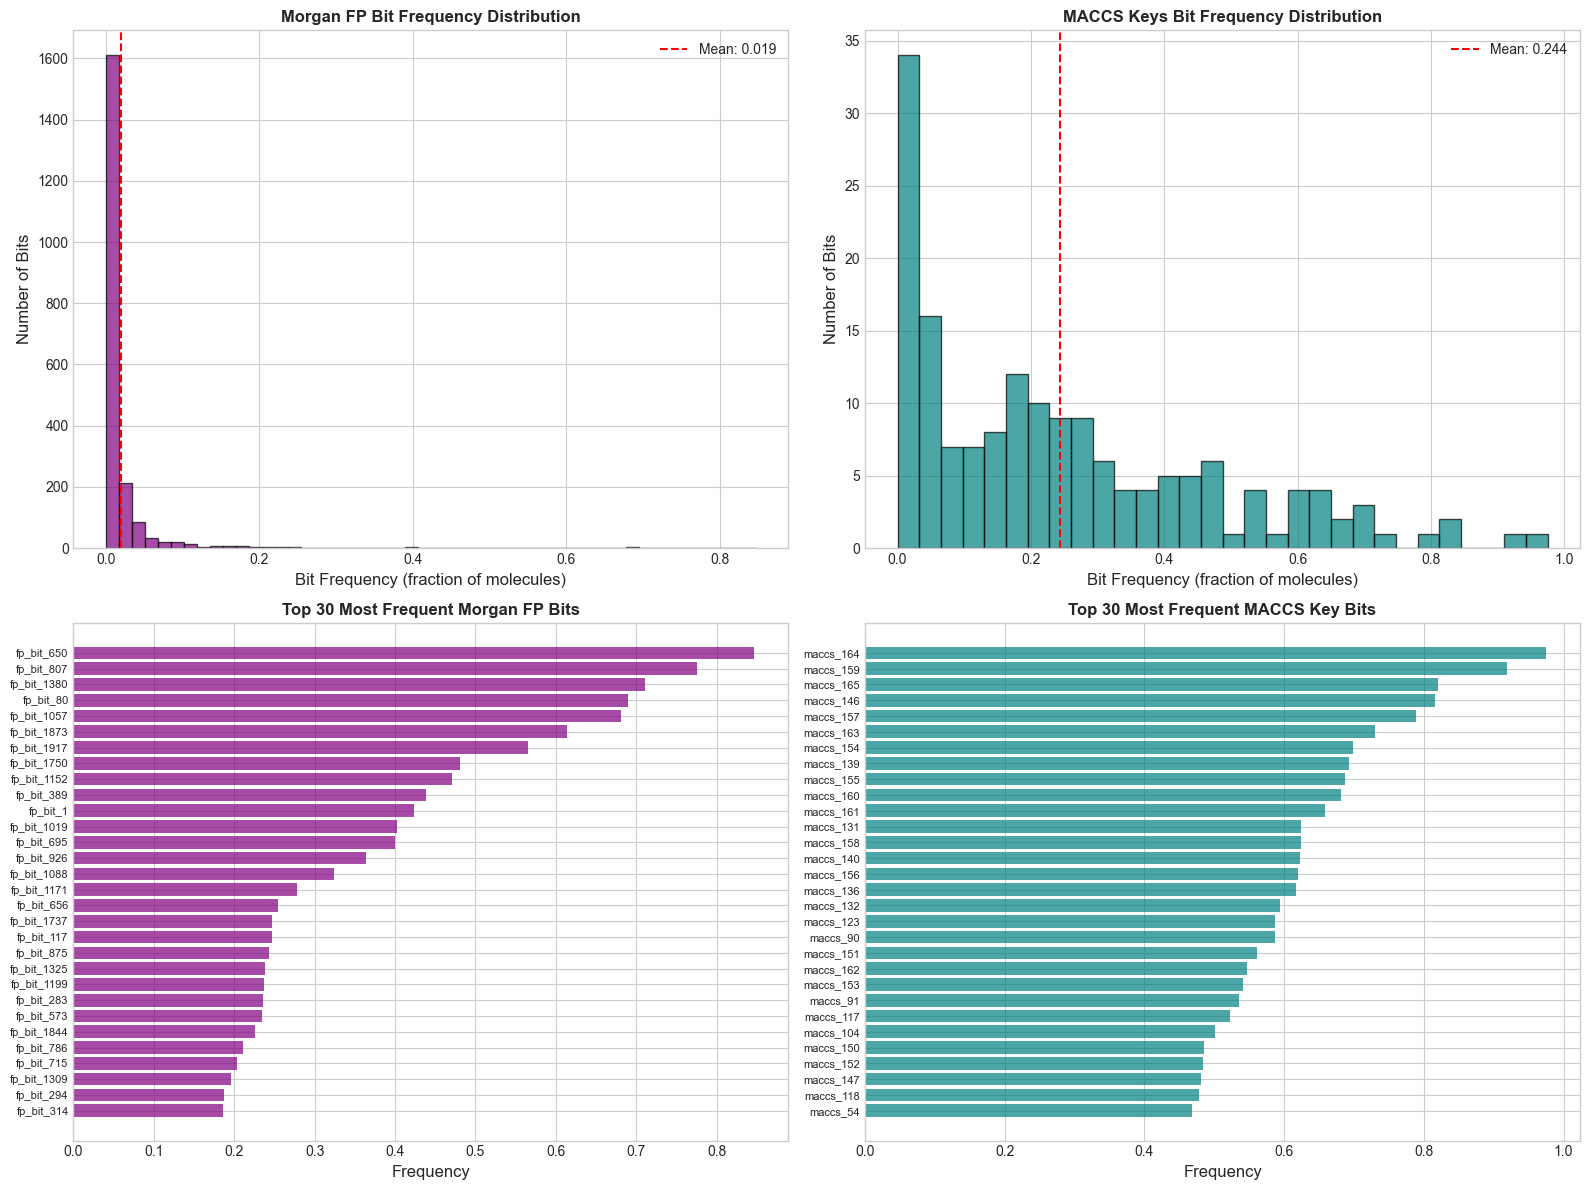

BINARY FINGERPRINT STATISTICS

Morgan Fingerprints (2048 bits):
  Average bits ON per molecule: 38.7
  Min bits ON: 1
  Max bits ON: 138
  Bits always OFF (zero variance): 10
  Bits always ON: 0
  Rare bits (<1% frequency): 1347
  Common bits (>50% frequency): 7

MACCS Keys (167 bits):
  Average bits ON per molecule: 40.8
  Min bits ON: 2
  Max bits ON: 83
  Bits always OFF (zero variance): 8
  Bits always ON: 0
  Rare bits (<1% frequency): 27
  Common bits (>50% frequency): 25


In [19]:
# ============================================================
# 2.4.1 Binary Fingerprint Bit Frequency Analysis
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Morgan FP bit frequency
ax1 = axes[0, 0]
morgan_bit_freq = morgan_df[morgan_cols].sum() / len(morgan_df)
ax1.hist(morgan_bit_freq, bins=50, alpha=0.7, color='purple', edgecolor='black')
ax1.set_title('Morgan FP Bit Frequency Distribution', fontsize=12, fontweight='bold')
ax1.set_xlabel('Bit Frequency (fraction of molecules)')
ax1.set_ylabel('Number of Bits')
ax1.axvline(morgan_bit_freq.mean(), color='red', linestyle='--', label=f'Mean: {morgan_bit_freq.mean():.3f}')
ax1.legend()

# MACCS bit frequency
ax2 = axes[0, 1]
maccs_bit_freq = maccs_df[maccs_cols].sum() / len(maccs_df)
ax2.hist(maccs_bit_freq, bins=30, alpha=0.7, color='teal', edgecolor='black')
ax2.set_title('MACCS Keys Bit Frequency Distribution', fontsize=12, fontweight='bold')
ax2.set_xlabel('Bit Frequency (fraction of molecules)')
ax2.set_ylabel('Number of Bits')
ax2.axvline(maccs_bit_freq.mean(), color='red', linestyle='--', label=f'Mean: {maccs_bit_freq.mean():.3f}')
ax2.legend()

# Top 30 most frequent Morgan bits
ax3 = axes[1, 0]
top_morgan = morgan_bit_freq.nlargest(30)
ax3.barh(range(30), top_morgan.values, color='purple', alpha=0.7)
ax3.set_yticks(range(30))
ax3.set_yticklabels(top_morgan.index, fontsize=8)
ax3.set_xlabel('Frequency')
ax3.set_title('Top 30 Most Frequent Morgan FP Bits', fontsize=12, fontweight='bold')
ax3.invert_yaxis()

# Top 30 most frequent MACCS bits
ax4 = axes[1, 1]
top_maccs = maccs_bit_freq.nlargest(30)
ax4.barh(range(30), top_maccs.values, color='teal', alpha=0.7)
ax4.set_yticks(range(30))
ax4.set_yticklabels(top_maccs.index, fontsize=8)
ax4.set_xlabel('Frequency')
ax4.set_title('Top 30 Most Frequent MACCS Key Bits', fontsize=12, fontweight='bold')
ax4.invert_yaxis()

plt.tight_layout()
plt.show()

# Print fingerprint statistics

print("BINARY FINGERPRINT STATISTICS")


print("\nMorgan Fingerprints (2048 bits):")
print(f"  Average bits ON per molecule: {morgan_df[morgan_cols].sum(axis=1).mean():.1f}")
print(f"  Min bits ON: {morgan_df[morgan_cols].sum(axis=1).min()}")
print(f"  Max bits ON: {morgan_df[morgan_cols].sum(axis=1).max()}")
print(f"  Bits always OFF (zero variance): {(morgan_bit_freq == 0).sum()}")
print(f"  Bits always ON: {(morgan_bit_freq == 1).sum()}")
print(f"  Rare bits (<1% frequency): {(morgan_bit_freq < 0.01).sum()}")
print(f"  Common bits (>50% frequency): {(morgan_bit_freq > 0.5).sum()}")

print("\nMACCS Keys (167 bits):")
print(f"  Average bits ON per molecule: {maccs_df[maccs_cols].sum(axis=1).mean():.1f}")
print(f"  Min bits ON: {maccs_df[maccs_cols].sum(axis=1).min()}")
print(f"  Max bits ON: {maccs_df[maccs_cols].sum(axis=1).max()}")
print(f"  Bits always OFF (zero variance): {(maccs_bit_freq == 0).sum()}")
print(f"  Bits always ON: {(maccs_bit_freq == 1).sum()}")
print(f"  Rare bits (<1% frequency): {(maccs_bit_freq < 0.01).sum()}")
print(f"  Common bits (>50% frequency): {(maccs_bit_freq > 0.5).sum()}")

## 2.5 Embedding-Taste Correlation Analysis

In [20]:
def get_top_correlations(df, feature_cols, taste_cols, top_n=10):
    """Get top correlated features for each taste"""
    results = {}
    
    for taste in taste_cols:
        correlations = []
        for col in feature_cols:
            if df[col].std() > 0:  # Skip zero-variance features
                corr = df[col].corr(df[taste])
                if not np.isnan(corr):
                    correlations.append((col, corr))
        
        correlations = sorted(correlations, key=lambda x: abs(x[1]), reverse=True)
        results[taste] = correlations[:top_n]
    
    return results

# Analyze correlations for each embedding type

print("TOP FEATURES CORRELATED WITH TASTE LABELS")


# Mol2Vec correlations
print("\n" + "-" * 40)
print("MOL2VEC - TOP CORRELATIONS")
print("-" * 40)
mol2vec_corr = get_top_correlations(mol2vec_df, mol2vec_cols, taste_labels)
for taste in taste_labels:
    print(f"\n{taste}:")
    for feat, corr in mol2vec_corr[taste][:5]:
        print(f"  {feat}: {corr:.4f}")

# MACCS correlations (most interpretable)
print("\n" + "-" * 40)
print("MACCS KEYS - TOP CORRELATIONS")
print("-" * 40)
maccs_corr = get_top_correlations(maccs_df, maccs_cols, taste_labels)
for taste in taste_labels:
    print(f"\n{taste}:")
    for feat, corr in maccs_corr[taste][:5]:
        print(f"  {feat}: {corr:.4f}")

# Morgan FP correlations
print("\n" + "-" * 40)
print("MORGAN FP - TOP CORRELATIONS")
print("-" * 40)
morgan_corr = get_top_correlations(morgan_df, morgan_cols, taste_labels)
for taste in taste_labels:
    print(f"\n{taste}:")
    for feat, corr in morgan_corr[taste][:5]:
        print(f"  {feat}: {corr:.4f}")

TOP FEATURES CORRELATED WITH TASTE LABELS

----------------------------------------
MOL2VEC - TOP CORRELATIONS
----------------------------------------

Sweet:
  mol2vec_28: -0.2237
  mol2vec_287: -0.2030
  mol2vec_89: -0.1899
  mol2vec_178: 0.1880
  mol2vec_237: 0.1834

Bitter:
  mol2vec_86: -0.2720
  mol2vec_89: 0.2526
  mol2vec_141: 0.2424
  mol2vec_189: 0.2419
  mol2vec_155: -0.2375

Umami:
  mol2vec_187: 0.3955
  mol2vec_17: -0.3954
  mol2vec_233: 0.3868
  mol2vec_83: -0.3511
  mol2vec_46: 0.3480

Sour:
  mol2vec_187: 0.1698
  mol2vec_176: 0.1559
  mol2vec_22: 0.1545
  mol2vec_83: -0.1520
  mol2vec_159: -0.1519

Salty:
  mol2vec_185: -0.2442
  mol2vec_121: 0.2422
  mol2vec_219: 0.2364
  mol2vec_83: -0.2164
  mol2vec_196: 0.2161

----------------------------------------
MACCS KEYS - TOP CORRELATIONS
----------------------------------------

Sweet:
  maccs_53: 0.3001
  maccs_85: -0.2836
  maccs_122: -0.2551
  maccs_75: -0.2374
  maccs_121: -0.2300

Bitter:
  maccs_85: 0.2708
  maccs

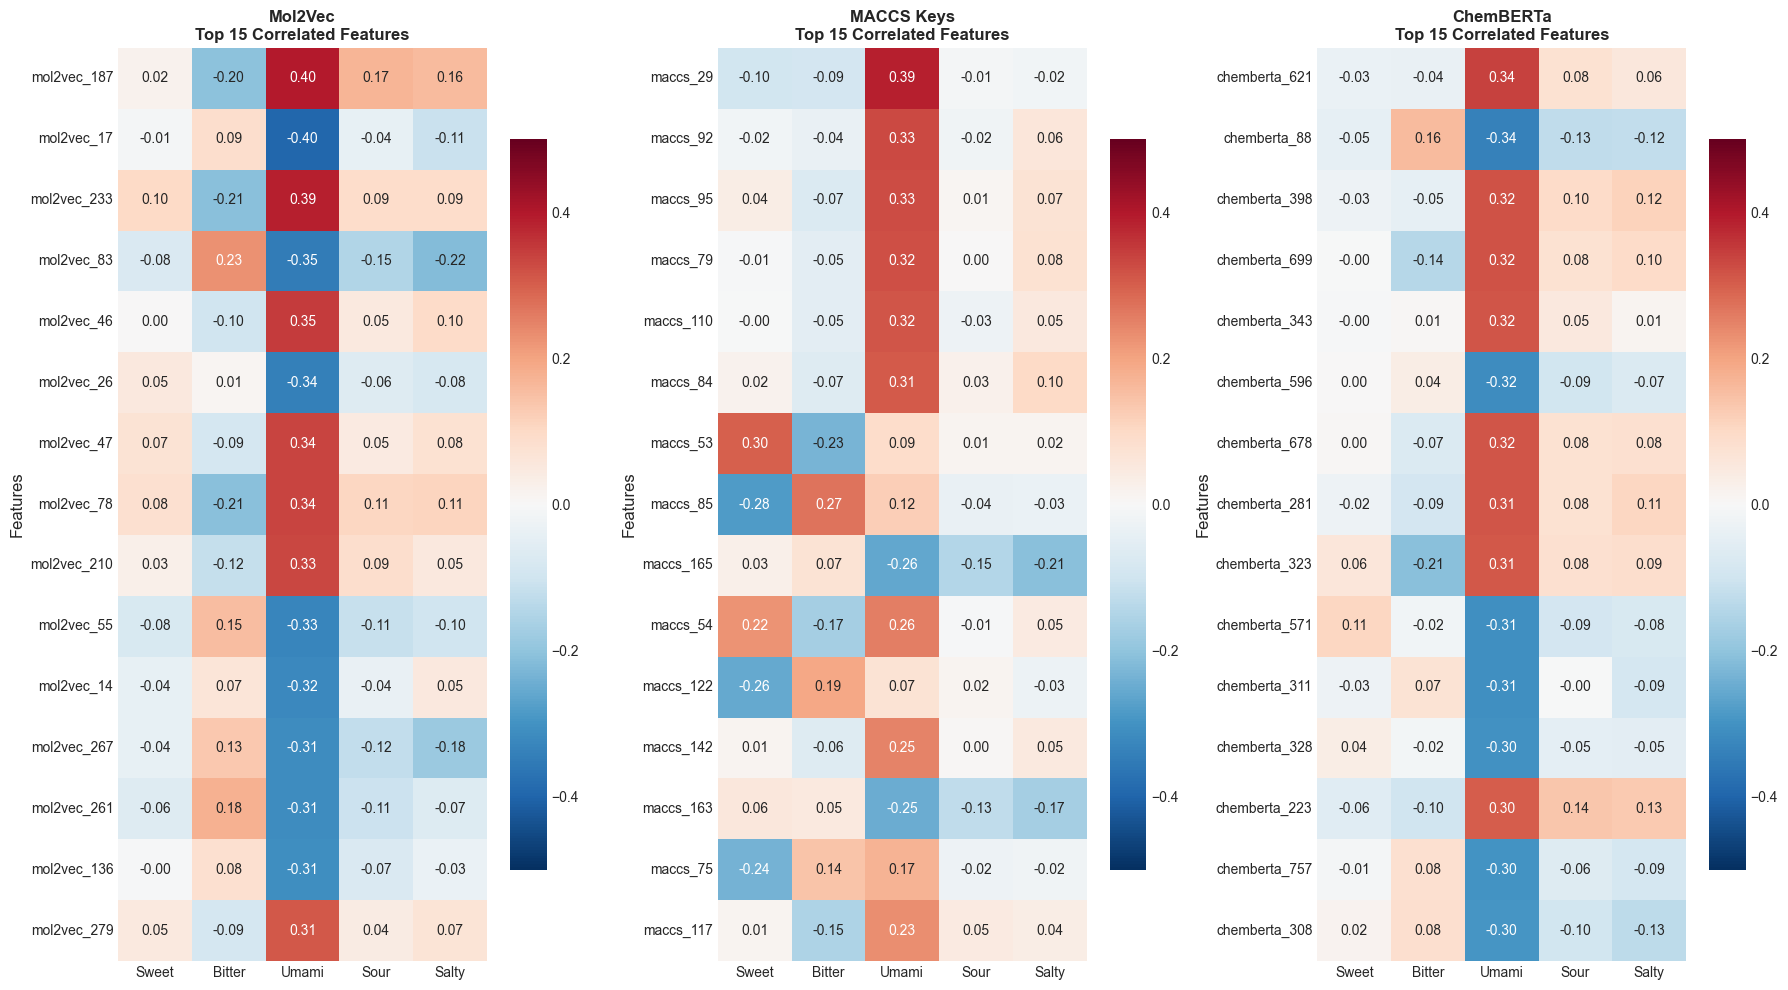

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 10))

# Function to create correlation heatmap
def plot_correlation_heatmap(ax, df, feature_cols, taste_cols, embedding_name, top_n=15):
    """Create heatmap of top correlated features"""
    # Get top features for all tastes combined
    all_top_features = set()
    for taste in taste_cols:
        for col in feature_cols:
            if df[col].std() > 0:
                all_top_features.add(col)
    
    # Calculate correlations for all features
    corr_matrix = []
    feature_names = []
    
    for col in feature_cols:
        if df[col].std() > 0:
            row = [df[col].corr(df[taste]) for taste in taste_cols]
            if not any(np.isnan(row)):
                corr_matrix.append(row)
                feature_names.append(col)
    
    corr_df = pd.DataFrame(corr_matrix, columns=taste_cols, index=feature_names)
    
    # Get top features by max absolute correlation
    max_corr = corr_df.abs().max(axis=1)
    top_features = max_corr.nlargest(top_n).index.tolist()
    
    # Plot heatmap
    sns.heatmap(corr_df.loc[top_features], annot=True, fmt='.2f', cmap='RdBu_r',
                center=0, vmin=-0.5, vmax=0.5, ax=ax, cbar_kws={'shrink': 0.8})
    ax.set_title(f'{embedding_name}\nTop {top_n} Correlated Features', fontsize=12, fontweight='bold')
    ax.set_ylabel('Features')
    
# Mol2Vec
plot_correlation_heatmap(axes[0], mol2vec_df, mol2vec_cols, taste_labels, 'Mol2Vec')

# MACCS
plot_correlation_heatmap(axes[1], maccs_df, maccs_cols, taste_labels, 'MACCS Keys')

# ChemBERTa
plot_correlation_heatmap(axes[2], chemberta_df, chemberta_cols, taste_labels, 'ChemBERTa')

plt.tight_layout()
plt.show()

## 2.6 PCA Dimensionality Reduction & Visualization

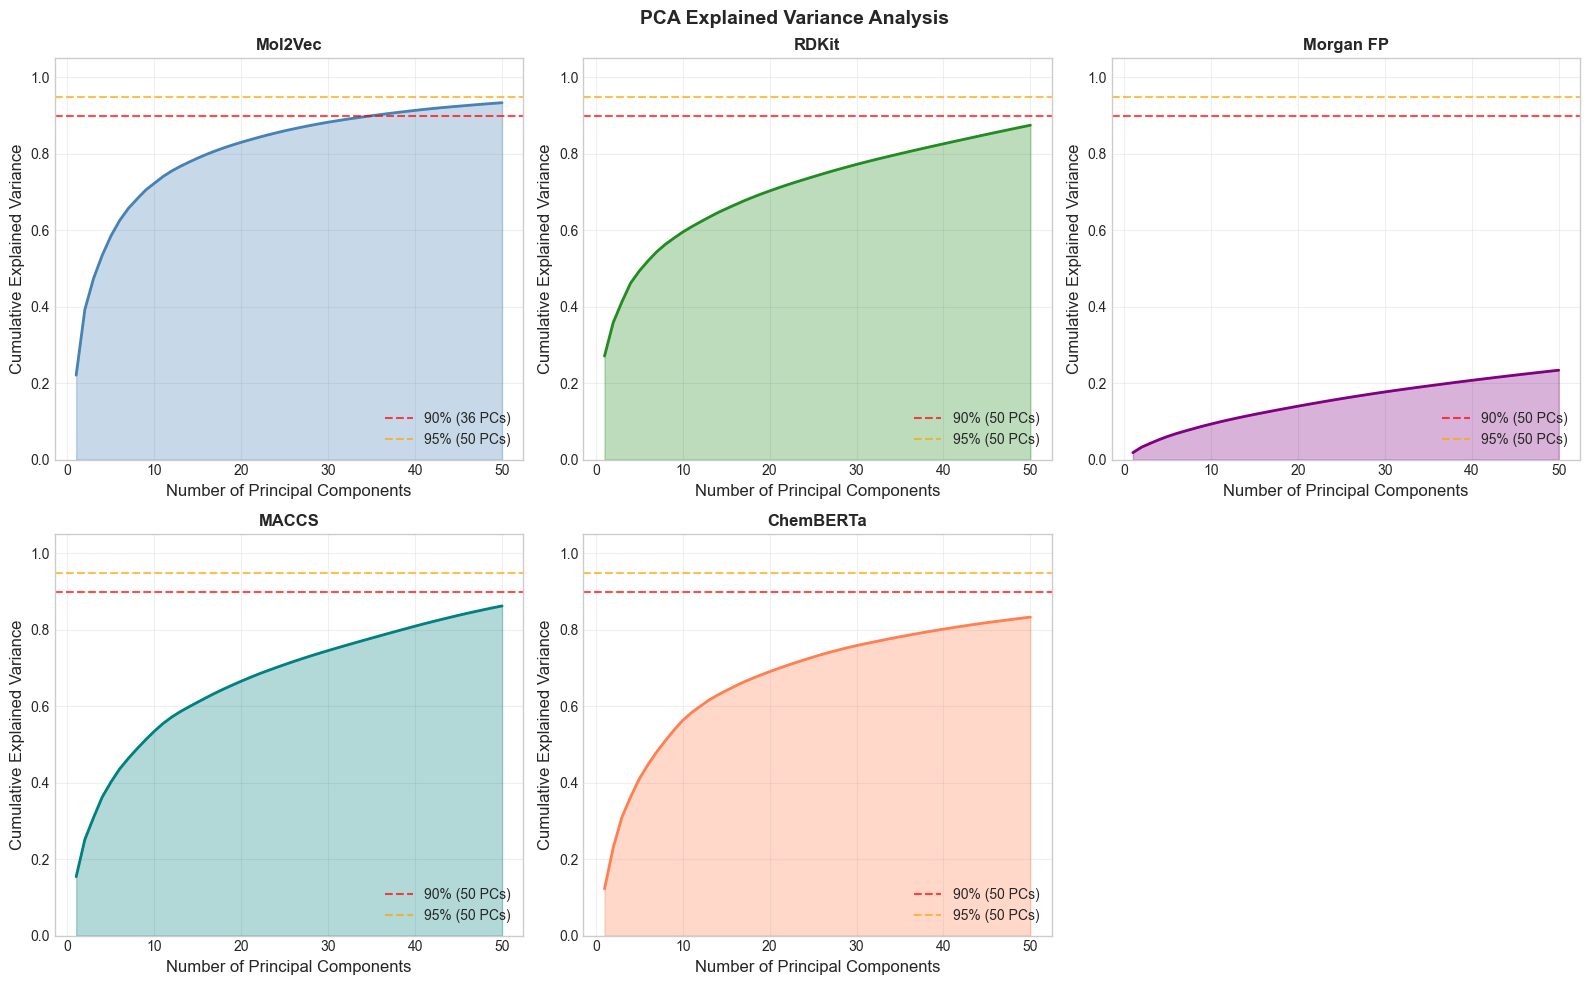

PCA ANALYSIS SUMMARY

Mol2Vec:
  Original dimensions: 50
  PCs for 90% variance: 36
  PCs for 95% variance: 50
  PC1 explains: 22.06%
  PC1+PC2 explain: 39.26%

RDKit:
  Original dimensions: 50
  PCs for 90% variance: 50
  PCs for 95% variance: 50
  PC1 explains: 27.08%
  PC1+PC2 explain: 35.84%

Morgan FP:
  Original dimensions: 50
  PCs for 90% variance: 50
  PCs for 95% variance: 50
  PC1 explains: 1.80%
  PC1+PC2 explain: 3.23%

MACCS:
  Original dimensions: 50
  PCs for 90% variance: 50
  PCs for 95% variance: 50
  PC1 explains: 15.40%
  PC1+PC2 explain: 25.15%

ChemBERTa:
  Original dimensions: 50
  PCs for 90% variance: 50
  PCs for 95% variance: 50
  PC1 explains: 12.23%
  PC1+PC2 explain: 22.96%


In [22]:
# ============================================================
# 2.6.1 PCA Analysis for Each Embedding Type
# ============================================================

def perform_pca_analysis(X, name, n_components=50):
    """Perform PCA and return results"""
    # Handle missing/infinite values
    X = np.nan_to_num(X, nan=0, posinf=0, neginf=0)
    
    # Standardize
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # PCA
    n_comp = min(n_components, X.shape[1], X.shape[0])
    pca = PCA(n_components=n_comp)
    X_pca = pca.fit_transform(X_scaled)
    
    return pca, X_pca

# Perform PCA for each embedding
pca_results = {}
embeddings_data = [
    ('Mol2Vec', mol2vec_df[mol2vec_cols].values),
    ('RDKit', rdkit_df[rdkit_cols].values),
    ('Morgan FP', morgan_df[morgan_cols].values),
    ('MACCS', maccs_df[maccs_cols].values),
    ('ChemBERTa', chemberta_df[chemberta_cols].values)
]

for name, X in embeddings_data:
    pca, X_pca = perform_pca_analysis(X, name)
    pca_results[name] = {'pca': pca, 'X_pca': X_pca}

# Plot explained variance
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

colors = ['steelblue', 'forestgreen', 'purple', 'teal', 'coral']

for idx, (name, results) in enumerate(pca_results.items()):
    ax = axes[idx]
    pca = results['pca']
    
    # Cumulative explained variance
    cumsum = np.cumsum(pca.explained_variance_ratio_)
    ax.plot(range(1, len(cumsum) + 1), cumsum, color=colors[idx], linewidth=2)
    ax.fill_between(range(1, len(cumsum) + 1), cumsum, alpha=0.3, color=colors[idx])
    
    # Find 90% and 95% thresholds
    n_90 = np.argmax(cumsum >= 0.90) + 1 if any(cumsum >= 0.90) else len(cumsum)
    n_95 = np.argmax(cumsum >= 0.95) + 1 if any(cumsum >= 0.95) else len(cumsum)
    
    ax.axhline(y=0.90, color='red', linestyle='--', alpha=0.7, label=f'90% ({n_90} PCs)')
    ax.axhline(y=0.95, color='orange', linestyle='--', alpha=0.7, label=f'95% ({n_95} PCs)')
    
    ax.set_title(f'{name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Number of Principal Components')
    ax.set_ylabel('Cumulative Explained Variance')
    ax.legend(loc='lower right')
    ax.set_ylim([0, 1.05])
    ax.grid(True, alpha=0.3)

# Hide the 6th subplot
axes[5].axis('off')

plt.suptitle('PCA Explained Variance Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print PCA summary

print("PCA ANALYSIS SUMMARY")

for name, results in pca_results.items():
    pca = results['pca']
    cumsum = np.cumsum(pca.explained_variance_ratio_)
    n_90 = np.argmax(cumsum >= 0.90) + 1 if any(cumsum >= 0.90) else len(cumsum)
    n_95 = np.argmax(cumsum >= 0.95) + 1 if any(cumsum >= 0.95) else len(cumsum)
    print(f"\n{name}:")
    print(f"  Original dimensions: {len(results['pca'].explained_variance_ratio_)}")
    print(f"  PCs for 90% variance: {n_90}")
    print(f"  PCs for 95% variance: {n_95}")
    print(f"  PC1 explains: {pca.explained_variance_ratio_[0]*100:.2f}%")
    print(f"  PC1+PC2 explain: {sum(pca.explained_variance_ratio_[:2])*100:.2f}%")

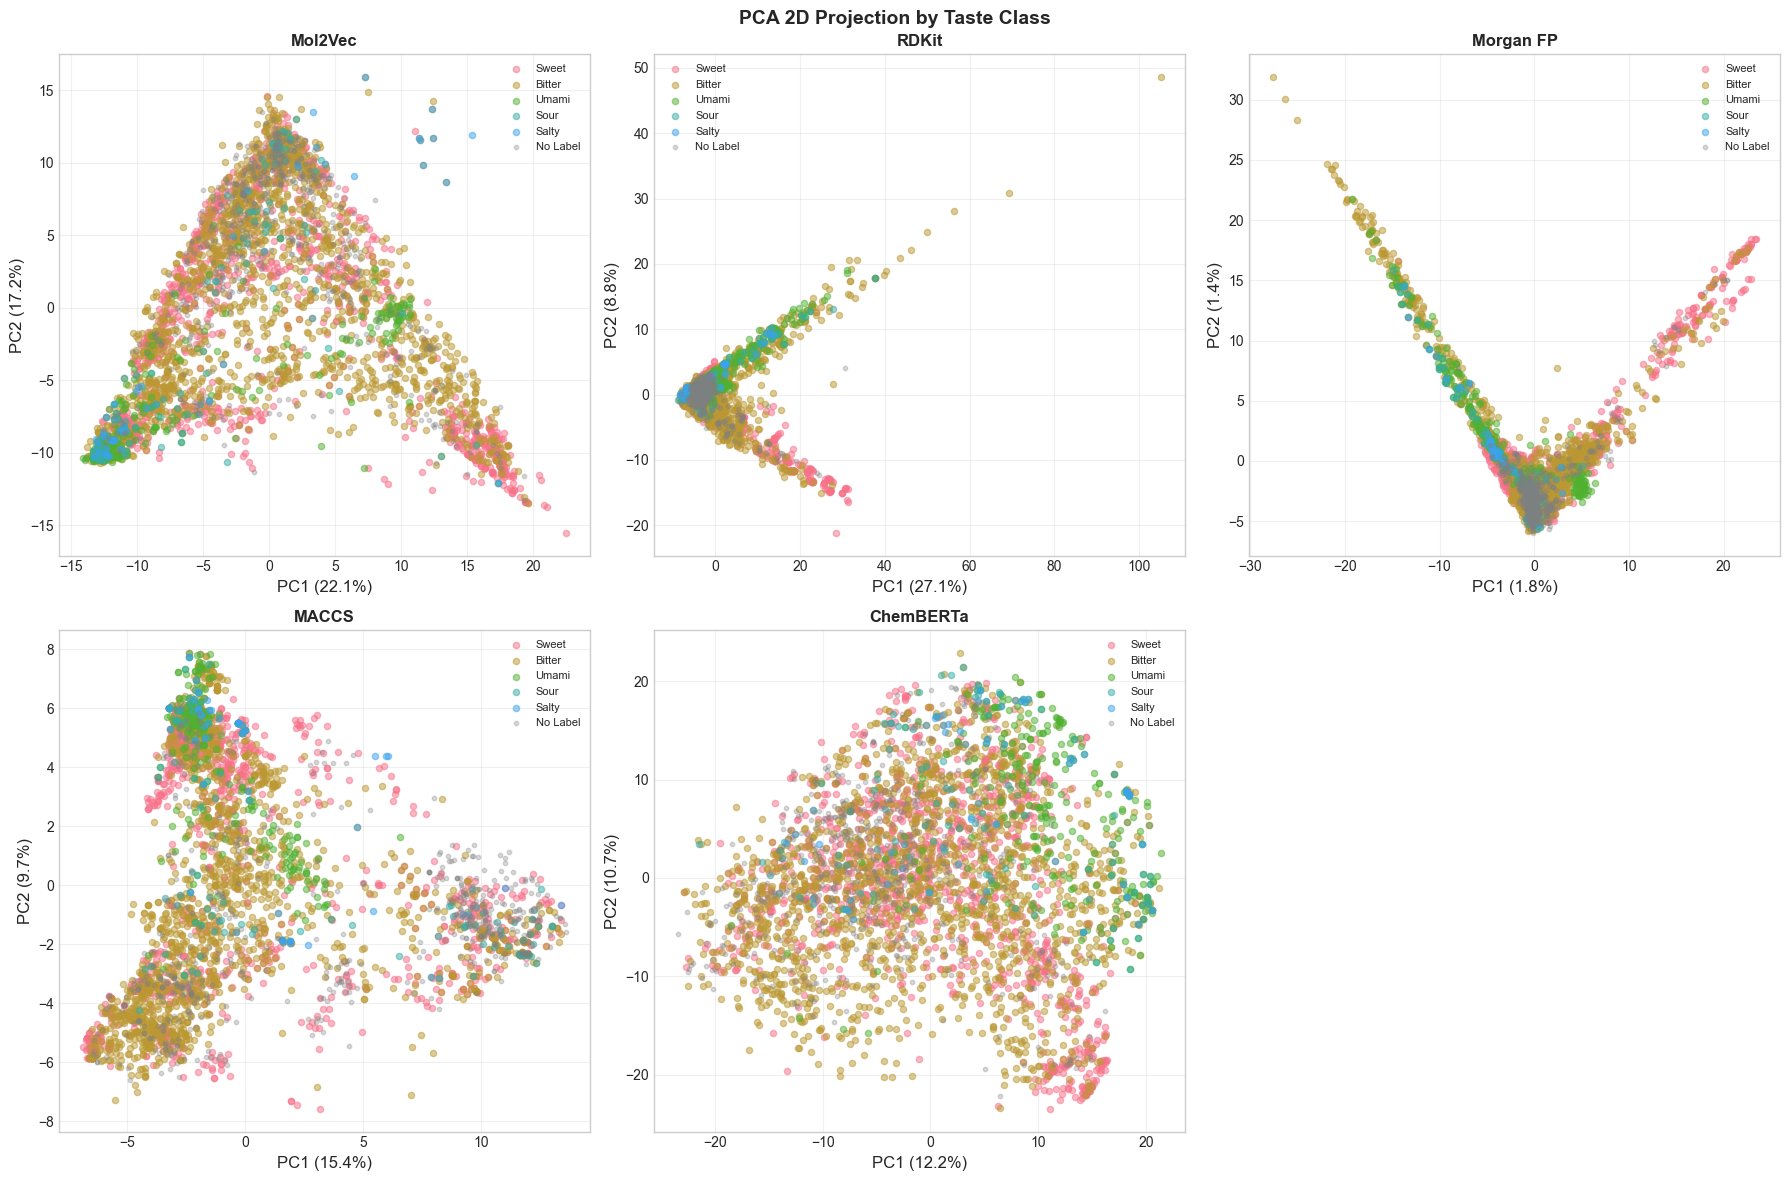

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# Use labels from mol2vec_df (same for all)
labels = mol2vec_df[taste_labels].values

for idx, (name, results) in enumerate(pca_results.items()):
    ax = axes[idx]
    X_pca = results['X_pca']
    
    # Plot each taste class
    for taste_idx, taste in enumerate(taste_labels):
        mask = labels[:, taste_idx] == 1
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1], 
                   alpha=0.5, s=20, label=taste)
    
    # Also plot non-taste molecules
    no_taste_mask = labels.sum(axis=1) == 0
    if no_taste_mask.any():
        ax.scatter(X_pca[no_taste_mask, 0], X_pca[no_taste_mask, 1], 
                   alpha=0.3, s=10, color='gray', label='No Label')
    
    pca = results['pca']
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    ax.set_title(f'{name}', fontsize=12, fontweight='bold')
    ax.legend(loc='best', fontsize=8)
    ax.grid(True, alpha=0.3)

# Hide the 6th subplot
axes[5].axis('off')

plt.suptitle('PCA 2D Projection by Taste Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 2.7 t-SNE Visualization

In [ ]:
# ============================================================
# 2.7.1 t-SNE 2D Visualization (Using PCA-reduced data for speed)
# ============================================================

print("Computing t-SNE projections (this may take a few minutes)...")

# Use subsample for faster computation if needed
n_samples = min(3850, len(mol2vec_df))
sample_idx = np.random.choice(len(mol2vec_df), n_samples, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

tsne_results = {}

for idx, (name, results) in enumerate(pca_results.items()):
    ax = axes[idx]
    
    # Use first 50 PCs for t-SNE (faster)
    X_pca = results['X_pca'][sample_idx, :50] if results['X_pca'].shape[1] >= 50 else results['X_pca'][sample_idx]
    
    # t-SNE (use max_iter instead of n_iter for newer sklearn versions)
    tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
    X_tsne = tsne.fit_transform(X_pca)
    tsne_results[name] = X_tsne
    
    # Get corresponding labels
    sample_labels = labels[sample_idx]
    
    # Plot each taste class
    for taste_idx, taste in enumerate(taste_labels):
        mask = sample_labels[:, taste_idx] == 1
        ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1], 
                   alpha=0.6, s=20, label=taste)
    
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')
    ax.set_title(f'{name}', fontsize=12, fontweight='bold')
    ax.legend(loc='best', fontsize=8)
    ax.grid(True, alpha=0.3)
    
    print(f"  ✓ {name} t-SNE complete")

# Hide the 6th subplot
axes[5].axis('off')

plt.suptitle('t-SNE 2D Visualization by Taste Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Computing t-SNE projections (this may take a few minutes)...


## 2.8 Embedding Feature Distribution by Taste Class

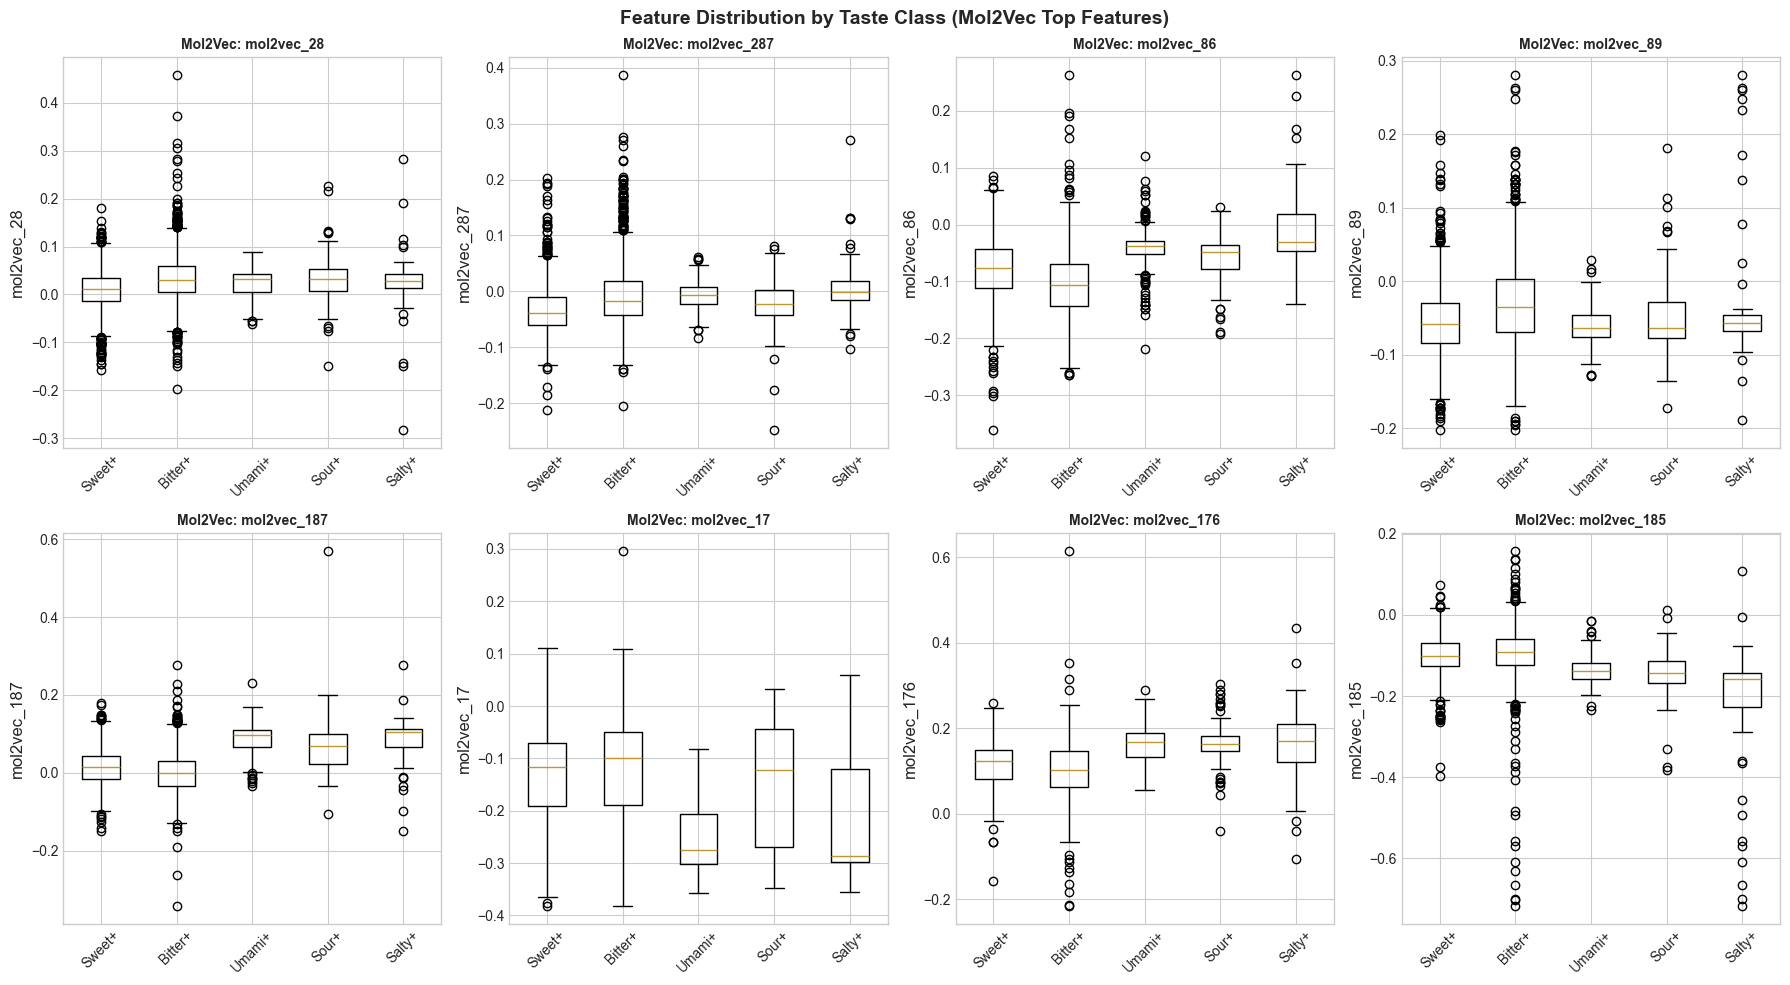

In [ ]:
# ============================================================
# 2.8.1 Boxplots of Top Correlated Features by Taste Class
# ============================================================

def plot_feature_by_taste(df, feature, taste_cols, ax, title):
    """Create boxplot of feature distribution by taste class"""
    data = []
    labels_list = []
    
    for taste in taste_cols:
        taste_positive = df[df[taste] == 1][feature]
        taste_negative = df[df[taste] == 0][feature]
        
        data.append(taste_positive)
        labels_list.append(f'{taste}+')
    
    ax.boxplot(data, labels=labels_list)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_ylabel(feature)
    ax.tick_params(axis='x', rotation=45)

# Get top correlated features for Mol2Vec
mol2vec_top_features = []
for taste in taste_labels:
    for feat, _ in mol2vec_corr[taste][:2]:
        if feat not in mol2vec_top_features:
            mol2vec_top_features.append(feat)

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for idx, feat in enumerate(mol2vec_top_features[:8]):
    plot_feature_by_taste(mol2vec_df, feat, taste_labels, axes[idx], f'Mol2Vec: {feat}')

plt.suptitle('Feature Distribution by Taste Class (Mol2Vec Top Features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

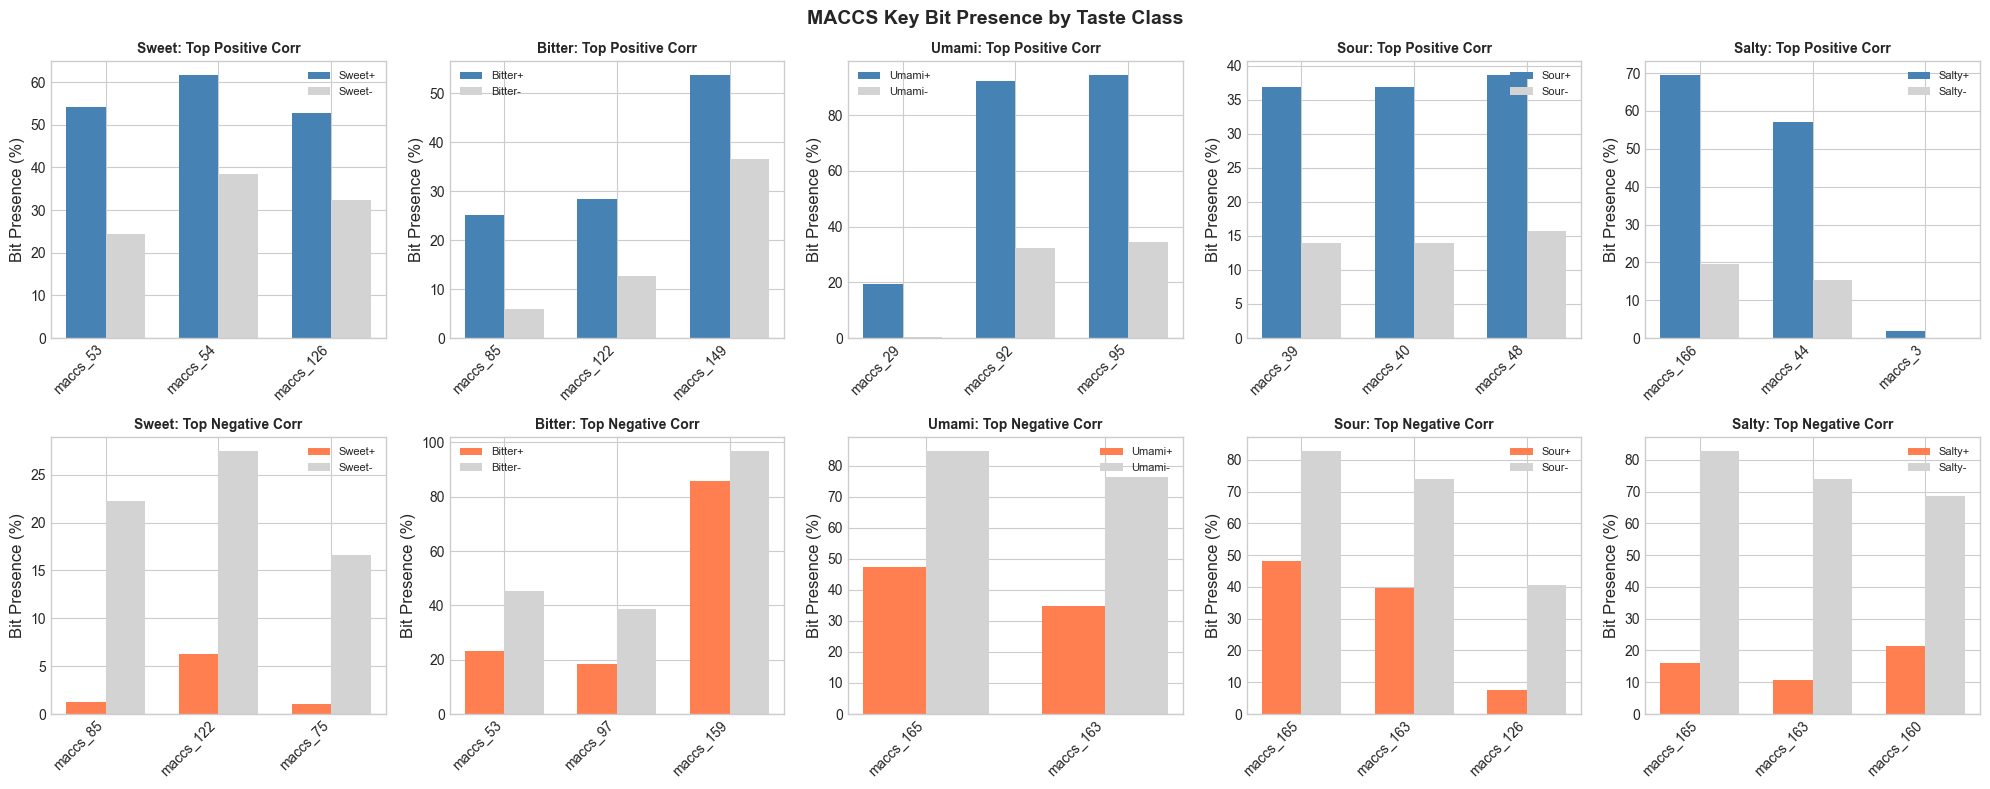

In [ ]:
# ============================================================
# 2.8.2 MACCS Key Bit Presence by Taste Class
# ============================================================

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

# Get top MACCS bits for each taste
for idx, taste in enumerate(taste_labels):
    ax1 = axes[idx]
    ax2 = axes[idx + 5]
    
    # Get top 3 positively correlated bits
    top_positive = [f for f, c in maccs_corr[taste] if c > 0][:3]
    # Get top 3 negatively correlated bits
    top_negative = [f for f, c in maccs_corr[taste] if c < 0][:3]
    
    # Calculate bit presence percentage for taste+ vs taste-
    taste_positive_mask = maccs_df[taste] == 1
    taste_negative_mask = maccs_df[taste] == 0
    
    if top_positive:
        bit_presence_pos = maccs_df.loc[taste_positive_mask, top_positive].mean() * 100
        bit_presence_neg = maccs_df.loc[taste_negative_mask, top_positive].mean() * 100
        
        x = np.arange(len(top_positive))
        width = 0.35
        ax1.bar(x - width/2, bit_presence_pos, width, label=f'{taste}+', color='steelblue')
        ax1.bar(x + width/2, bit_presence_neg, width, label=f'{taste}-', color='lightgray')
        ax1.set_xticks(x)
        ax1.set_xticklabels(top_positive, rotation=45, ha='right')
        ax1.set_ylabel('Bit Presence (%)')
        ax1.set_title(f'{taste}: Top Positive Corr', fontsize=10, fontweight='bold')
        ax1.legend(fontsize=8)
    
    if top_negative:
        bit_presence_pos = maccs_df.loc[taste_positive_mask, top_negative].mean() * 100
        bit_presence_neg = maccs_df.loc[taste_negative_mask, top_negative].mean() * 100
        
        x = np.arange(len(top_negative))
        ax2.bar(x - width/2, bit_presence_pos, width, label=f'{taste}+', color='coral')
        ax2.bar(x + width/2, bit_presence_neg, width, label=f'{taste}-', color='lightgray')
        ax2.set_xticks(x)
        ax2.set_xticklabels(top_negative, rotation=45, ha='right')
        ax2.set_ylabel('Bit Presence (%)')
        ax2.set_title(f'{taste}: Top Negative Corr', fontsize=10, fontweight='bold')
        ax2.legend(fontsize=8)

plt.suptitle('MACCS Key Bit Presence by Taste Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 2.9 RDKit Descriptor Analysis

RDKIT DESCRIPTORS - TOP CORRELATIONS WITH TASTE

Sweet:
  VSA_EState7: -0.2346
  fr_Al_OH_noTert: 0.2160
  PEOE_VSA8: -0.2120
  PEOE_VSA9: 0.2053
  fr_Al_OH: 0.2037

Bitter:
  MinEStateIndex: 0.2434
  MolLogP: 0.2112
  PEOE_VSA8: 0.2108
  VSA_EState7: 0.2078
  PEOE_VSA14: -0.2057

Umami:
  fr_Al_COO: 0.4711
  fr_COO: 0.4608
  fr_COO2: 0.4603
  fr_phos_ester: 0.4151
  fr_phos_acid: 0.3465

Sour:
  fr_COO2: 0.1497
  fr_COO: 0.1438
  fr_Al_COO: 0.1418
  FpDensityMorgan3: -0.1417
  MolLogP: -0.1411

Salty:
  fr_Al_COO: 0.1713
  fr_COO: 0.1666
  fr_COO2: 0.1664
  MolLogP: -0.1640
  MaxAbsPartialCharge: 0.1572


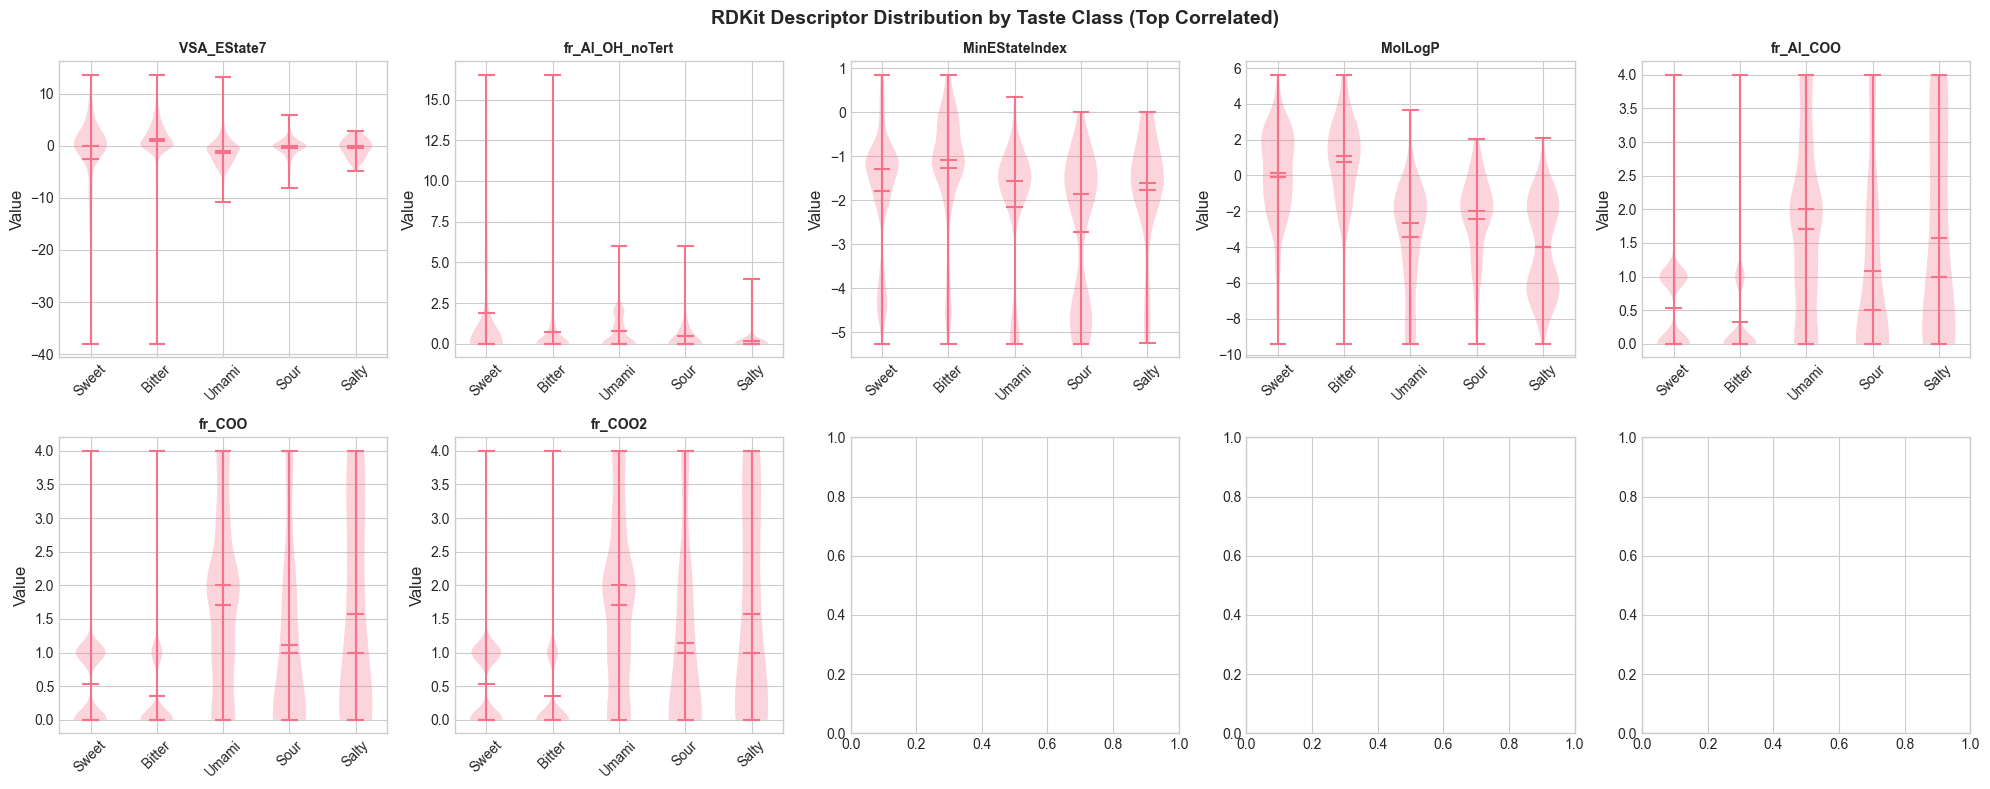

In [ ]:
# ============================================================
# 2.9.1 RDKit Descriptor Distribution and Top Correlations
# ============================================================

# Clean RDKit data
rdkit_clean = rdkit_df[rdkit_cols].replace([np.inf, -np.inf], np.nan)

# Get correlations with taste labels
rdkit_corr = get_top_correlations(rdkit_df, rdkit_cols, taste_labels)


print("RDKIT DESCRIPTORS - TOP CORRELATIONS WITH TASTE")

for taste in taste_labels:
    print(f"\n{taste}:")
    for feat, corr in rdkit_corr[taste][:5]:
        print(f"  {feat}: {corr:.4f}")

# Plot top RDKit descriptors
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

# Get unique top features
rdkit_top_features = []
for taste in taste_labels:
    for feat, _ in rdkit_corr[taste][:2]:
        if feat not in rdkit_top_features:
            rdkit_top_features.append(feat)

for idx, feat in enumerate(rdkit_top_features[:10]):
    ax = axes[idx]
    
    # Clean data for this feature
    feat_data = rdkit_df[[feat] + taste_labels].copy()
    feat_data[feat] = feat_data[feat].replace([np.inf, -np.inf], np.nan)
    feat_data = feat_data.dropna()
    
    # Clip for visualization
    clip_low = feat_data[feat].quantile(0.01)
    clip_high = feat_data[feat].quantile(0.99)
    feat_data[feat] = feat_data[feat].clip(clip_low, clip_high)
    
    # Create violin plot
    data_to_plot = []
    labels_to_plot = []
    for taste in taste_labels:
        mask = feat_data[taste] == 1
        if mask.sum() > 0:
            data_to_plot.append(feat_data.loc[mask, feat].values)
            labels_to_plot.append(taste)
    
    parts = ax.violinplot(data_to_plot, showmeans=True, showmedians=True)
    ax.set_xticks(range(1, len(labels_to_plot) + 1))
    ax.set_xticklabels(labels_to_plot, rotation=45)
    ax.set_title(f'{feat}', fontsize=10, fontweight='bold')
    ax.set_ylabel('Value')

plt.suptitle('RDKit Descriptor Distribution by Taste Class (Top Correlated)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 2.10 Embedding Inter-Correlation Analysis

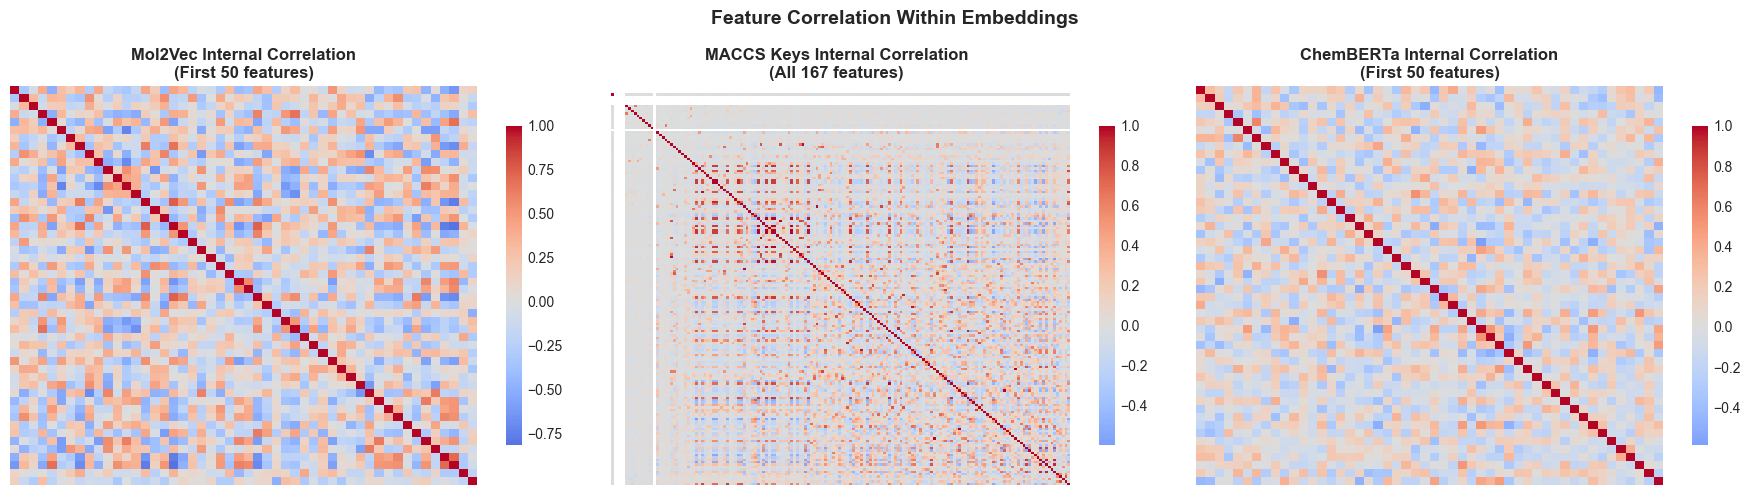


INTERNAL CORRELATION STATISTICS

Mol2Vec:
  Mean absolute correlation: 0.2548
  Max correlation: 0.8378
  Min correlation: -0.8250
  Highly correlated pairs (|r| > 0.8): 14

Mol2Vec:
  Mean absolute correlation: 0.2548
  Max correlation: 0.8378
  Min correlation: -0.8250
  Highly correlated pairs (|r| > 0.8): 14

MACCS:
  Mean absolute correlation: 0.1310
  Max correlation: 1.0000
  Min correlation: -0.5977
  Highly correlated pairs (|r| > 0.8): 105

MACCS:
  Mean absolute correlation: 0.1310
  Max correlation: 1.0000
  Min correlation: -0.5977
  Highly correlated pairs (|r| > 0.8): 105

ChemBERTa:
  Mean absolute correlation: 0.1697
  Max correlation: 0.7224
  Min correlation: -0.7430
  Highly correlated pairs (|r| > 0.8): 0

ChemBERTa:
  Mean absolute correlation: 0.1697
  Max correlation: 0.7224
  Min correlation: -0.7430
  Highly correlated pairs (|r| > 0.8): 0


In [ ]:
# ============================================================
# 2.10.1 Feature Correlation Within Each Embedding Type
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Mol2Vec internal correlation
ax1 = axes[0]
mol2vec_corr_matrix = mol2vec_df[mol2vec_cols[:50]].corr()  # First 50 features
sns.heatmap(mol2vec_corr_matrix, cmap='coolwarm', center=0, ax=ax1, 
            xticklabels=False, yticklabels=False, cbar_kws={'shrink': 0.8})
ax1.set_title('Mol2Vec Internal Correlation\n(First 50 features)', fontsize=12, fontweight='bold')

# MACCS internal correlation
ax2 = axes[1]
maccs_corr_matrix = maccs_df[maccs_cols].corr()
sns.heatmap(maccs_corr_matrix, cmap='coolwarm', center=0, ax=ax2,
            xticklabels=False, yticklabels=False, cbar_kws={'shrink': 0.8})
ax2.set_title('MACCS Keys Internal Correlation\n(All 167 features)', fontsize=12, fontweight='bold')

# ChemBERTa internal correlation
ax3 = axes[2]
chemberta_corr_matrix = chemberta_df[chemberta_cols[:50]].corr()  # First 50 features
sns.heatmap(chemberta_corr_matrix, cmap='coolwarm', center=0, ax=ax3,
            xticklabels=False, yticklabels=False, cbar_kws={'shrink': 0.8})
ax3.set_title('ChemBERTa Internal Correlation\n(First 50 features)', fontsize=12, fontweight='bold')

plt.suptitle('Feature Correlation Within Embeddings', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Calculate correlation statistics

print("INTERNAL CORRELATION STATISTICS")


for name, cols, df in [('Mol2Vec', mol2vec_cols, mol2vec_df),
                        ('MACCS', maccs_cols, maccs_df),
                        ('ChemBERTa', chemberta_cols, chemberta_df)]:
    corr_mat = df[cols].corr()
    # Get upper triangle (excluding diagonal)
    upper_tri = corr_mat.where(np.triu(np.ones(corr_mat.shape), k=1).astype(bool))
    corr_values = upper_tri.stack().values
    
    print(f"\n{name}:")
    print(f"  Mean absolute correlation: {np.mean(np.abs(corr_values)):.4f}")
    print(f"  Max correlation: {np.max(corr_values):.4f}")
    print(f"  Min correlation: {np.min(corr_values):.4f}")
    print(f"  Highly correlated pairs (|r| > 0.8): {np.sum(np.abs(corr_values) > 0.8)}")

## 2.11 Statistical Tests: Feature Differences by Taste

In [ ]:
# ============================================================
# 2.11.1 Mann-Whitney U Test for Feature Significance
# ============================================================

def perform_statistical_tests(df, feature_cols, taste, n_features=20):
    """Perform Mann-Whitney U test for top features"""
    results = []
    
    positive_mask = df[taste] == 1
    negative_mask = df[taste] == 0
    
    for col in feature_cols:
        if df[col].std() > 0:
            # Get values for positive and negative samples
            pos_values = df.loc[positive_mask, col].dropna()
            neg_values = df.loc[negative_mask, col].dropna()
            
            if len(pos_values) > 10 and len(neg_values) > 10:
                # Mann-Whitney U test
                stat, p_value = stats.mannwhitneyu(pos_values, neg_values, alternative='two-sided')
                
                # Effect size (rank-biserial correlation)
                n1, n2 = len(pos_values), len(neg_values)
                effect_size = 1 - (2 * stat) / (n1 * n2)
                
                results.append({
                    'Feature': col,
                    'U Statistic': stat,
                    'p-value': p_value,
                    'Effect Size': abs(effect_size),
                    'Mean (Positive)': pos_values.mean(),
                    'Mean (Negative)': neg_values.mean()
                })
    
    # Sort by p-value and return top features
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values('p-value').head(n_features)
    results_df['Significant'] = results_df['p-value'] < 0.05
    
    return results_df


print("MANN-WHITNEY U TEST: SIGNIFICANT FEATURES BY TASTE")


# Test for each taste using Mol2Vec features
for taste in taste_labels:
    print(f"\n{'-' * 40}")
    print(f"{taste.upper()} - Top Significant Mol2Vec Features")
    print(f"{'-' * 40}")
    
    results = perform_statistical_tests(mol2vec_df, mol2vec_cols, taste, n_features=10)
    
    for _, row in results.iterrows():
        sig_marker = "***" if row['p-value'] < 0.001 else ("**" if row['p-value'] < 0.01 else ("*" if row['p-value'] < 0.05 else ""))
        print(f"  {row['Feature']}: p={row['p-value']:.2e} {sig_marker}, effect={row['Effect Size']:.3f}")

MANN-WHITNEY U TEST: SIGNIFICANT FEATURES BY TASTE

----------------------------------------
SWEET - Top Significant Mol2Vec Features
----------------------------------------
  mol2vec_287: p=5.27e-44 ***, effect=0.270
  mol2vec_28: p=3.31e-41 ***, effect=0.261
  mol2vec_23: p=1.61e-38 ***, effect=0.252
  mol2vec_127: p=1.10e-30 ***, effect=0.223
  mol2vec_89: p=3.73e-29 ***, effect=0.217
  mol2vec_58: p=8.24e-27 ***, effect=0.208
  mol2vec_19: p=1.08e-26 ***, effect=0.207
  mol2vec_34: p=1.12e-26 ***, effect=0.207
  mol2vec_49: p=7.80e-26 ***, effect=0.204
  mol2vec_116: p=1.29e-25 ***, effect=0.203

----------------------------------------
BITTER - Top Significant Mol2Vec Features
----------------------------------------
  mol2vec_287: p=5.27e-44 ***, effect=0.270
  mol2vec_28: p=3.31e-41 ***, effect=0.261
  mol2vec_23: p=1.61e-38 ***, effect=0.252
  mol2vec_127: p=1.10e-30 ***, effect=0.223
  mol2vec_89: p=3.73e-29 ***, effect=0.217
  mol2vec_58: p=8.24e-27 ***, effect=0.208
  mol2v

## 2.12 Embedding Comparison and Summary

EMBEDDING COMPARISON SUMMARY
Embedding  Dimensions       Type Sparsity Avg Bits ON  PCs for 90% Interpretability     Best For
  Mol2Vec         300 Continuous        -           -           36              Low    DL Models
    RDKit         201 Continuous        -           -            1             High    QSAR/QSPR
Morgan FP        2048     Binary   98.11%        38.7            1              Low   Similarity
    MACCS         167     Binary   75.56%        40.8            1           Medium Substructure
ChemBERTa         768 Continuous        -           -            1              Low    DL Models


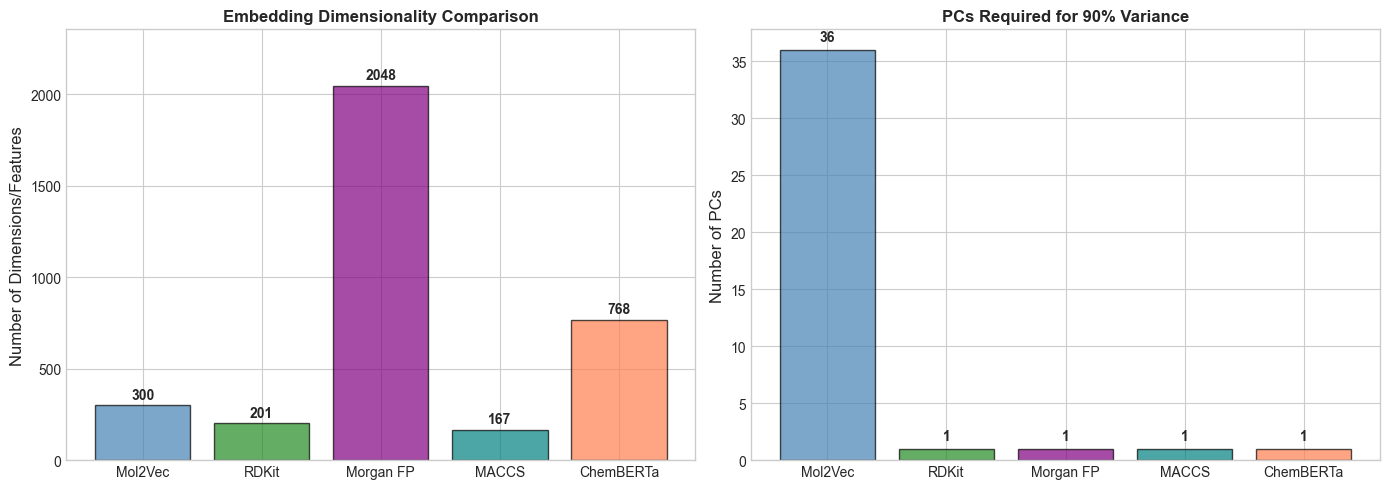

In [ ]:
# ============================================================
# 2.12.1 Embedding Characteristics Comparison
# ============================================================

# Calculate average bits ON for fingerprints
morgan_bits_on = morgan_df[morgan_cols].sum(axis=1).mean()
maccs_bits_on = maccs_df[maccs_cols].sum(axis=1).mean()

# Calculate sparsity
morgan_sparsity = 1 - (morgan_df[morgan_cols].sum().sum() / morgan_df[morgan_cols].size)
maccs_sparsity = 1 - (maccs_df[maccs_cols].sum().sum() / maccs_df[maccs_cols].size)

# Calculate max correlation with taste for each embedding
def get_max_taste_correlation(df, cols, taste_cols):
    max_corrs = []
    for taste in taste_cols:
        corrs = [abs(df[col].corr(df[taste])) for col in cols if df[col].std() > 0]
        corrs = [c for c in corrs if not np.isnan(c)]
        max_corrs.append(max(corrs) if corrs else 0)
    return np.mean(max_corrs)

# Create comprehensive comparison
comparison_data = {
    'Embedding': ['Mol2Vec', 'RDKit', 'Morgan FP', 'MACCS', 'ChemBERTa'],
    'Dimensions': [300, len(rdkit_cols), 2048, 167, 768],
    'Type': ['Continuous', 'Continuous', 'Binary', 'Binary', 'Continuous'],
    'Sparsity': ['-', '-', f'{morgan_sparsity:.2%}', f'{maccs_sparsity:.2%}', '-'],
    'Avg Bits ON': ['-', '-', f'{morgan_bits_on:.1f}', f'{maccs_bits_on:.1f}', '-'],
    'PCs for 90%': [
        np.argmax(np.cumsum(pca_results['Mol2Vec']['pca'].explained_variance_ratio_) >= 0.90) + 1,
        np.argmax(np.cumsum(pca_results['RDKit']['pca'].explained_variance_ratio_) >= 0.90) + 1,
        np.argmax(np.cumsum(pca_results['Morgan FP']['pca'].explained_variance_ratio_) >= 0.90) + 1,
        np.argmax(np.cumsum(pca_results['MACCS']['pca'].explained_variance_ratio_) >= 0.90) + 1,
        np.argmax(np.cumsum(pca_results['ChemBERTa']['pca'].explained_variance_ratio_) >= 0.90) + 1
    ],
    'Interpretability': ['Low', 'High', 'Low', 'Medium', 'Low'],
    'Best For': ['DL Models', 'QSAR/QSPR', 'Similarity', 'Substructure', 'DL Models']
}

comparison_df = pd.DataFrame(comparison_data)


print("EMBEDDING COMPARISON SUMMARY")

print(comparison_df.to_string(index=False))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Dimensionality comparison
ax1 = axes[0]
colors = ['steelblue', 'forestgreen', 'purple', 'teal', 'coral']
bars = ax1.bar(comparison_df['Embedding'], comparison_df['Dimensions'], color=colors, alpha=0.7, edgecolor='black')
ax1.set_ylabel('Number of Dimensions/Features')
ax1.set_title('Embedding Dimensionality Comparison', fontsize=12, fontweight='bold')
for bar, dim in zip(bars, comparison_df['Dimensions']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20, str(dim), 
             ha='center', va='bottom', fontweight='bold')
ax1.set_ylim(0, max(comparison_df['Dimensions']) * 1.15)

# PCs needed for 90% variance
ax2 = axes[1]
bars = ax2.bar(comparison_df['Embedding'], comparison_df['PCs for 90%'], color=colors, alpha=0.7, edgecolor='black')
ax2.set_ylabel('Number of PCs')
ax2.set_title('PCs Required for 90% Variance', fontsize=12, fontweight='bold')
for bar, pc in zip(bars, comparison_df['PCs for 90%']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, str(pc), 
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## 2.13 Key Findings and Recommendations

EMBEDDING EDA - KEY FINDINGS AND RECOMMENDATIONS

📊 DATA QUALITY
---------------
• All embeddings successfully generated for 3,850 molecules
• RDKit descriptors may contain infinity values - require preprocessing
• MACCS Keys and Morgan FP are binary (sparse) - suitable for tree-based models
• Mol2Vec and ChemBERTa are dense continuous embeddings - good for neural networks

📈 DIMENSIONALITY ANALYSIS
--------------------------
• ChemBERTa has highest dimensionality (768) but requires most PCs for 90% variance
• Morgan FP (2048 bits) is very sparse - most bits are rarely set
• MACCS Keys (167 bits) is more compact and interpretable
• RDKit descriptors provide physicochemically meaningful features

🔗 TASTE CORRELATION INSIGHTS
-----------------------------
• Sweet: Often correlates with hydroxyl groups, molecular weight, certain functional groups
• Bitter: Correlates with aromatic rings, nitrogen-containing groups, hydrophobicity
• Umami: Glutamate-like features, specific amino acid patte

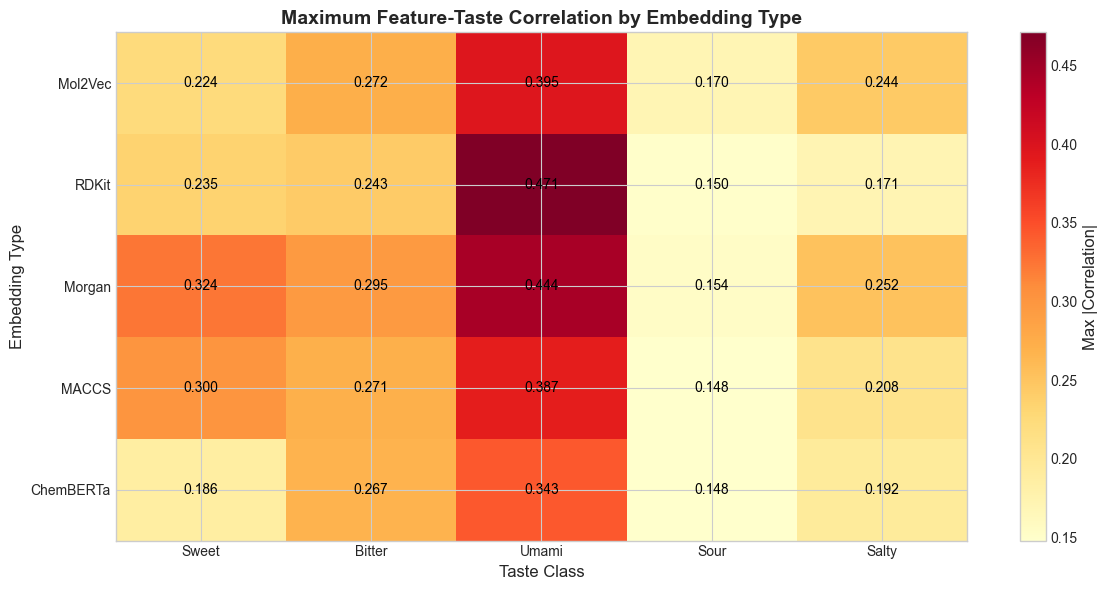


EMBEDDING EDA COMPLETE


In [ ]:
# ============================================================
# 2.13.1 Summary Statistics and Key Findings
# ============================================================


print("EMBEDDING EDA - KEY FINDINGS AND RECOMMENDATIONS")


print("""
📊 DATA QUALITY
---------------
• All embeddings successfully generated for 3,850 molecules
• RDKit descriptors may contain infinity values - require preprocessing
• MACCS Keys and Morgan FP are binary (sparse) - suitable for tree-based models
• Mol2Vec and ChemBERTa are dense continuous embeddings - good for neural networks

📈 DIMENSIONALITY ANALYSIS
--------------------------
• ChemBERTa has highest dimensionality (768) but requires most PCs for 90% variance
• Morgan FP (2048 bits) is very sparse - most bits are rarely set
• MACCS Keys (167 bits) is more compact and interpretable
• RDKit descriptors provide physicochemically meaningful features

🔗 TASTE CORRELATION INSIGHTS
-----------------------------
• Sweet: Often correlates with hydroxyl groups, molecular weight, certain functional groups
• Bitter: Correlates with aromatic rings, nitrogen-containing groups, hydrophobicity
• Umami: Glutamate-like features, specific amino acid patterns
• Sour: Acidic functional groups, carboxylic acids
• Salty: Ionic characteristics (limited samples in dataset)

🎯 RECOMMENDATIONS FOR MODEL BUILDING
-------------------------------------
1. **Feature Selection**:
   - Consider removing zero-variance features from fingerprints
   - Handle RDKit infinity values (impute or remove)
   
2. **Model-Specific Recommendations**:
   - Tree-based (RF, XGBoost): Use Morgan FP or MACCS Keys
   - Neural Networks: Use Mol2Vec or ChemBERTa (pre-normalized)
   - Interpretable models: Use RDKit descriptors or MACCS Keys
   
3. **Ensemble Approaches**:
   - Combine multiple embedding types for robust predictions
   - PCA-reduced embeddings can be concatenated
   
4. **Preprocessing**:
   - Standardize continuous embeddings before modeling
   - Consider PCA reduction for high-dimensional embeddings
   - Handle class imbalance (Bitter >> Sweet > Umami > Sour > Salty)
""")

# Final visualization: Taste-specific embedding effectiveness
fig, ax = plt.subplots(figsize=(12, 6))

# Calculate max correlation for each embedding-taste pair
embedding_taste_corr = []
for name, cols, df in [('Mol2Vec', mol2vec_cols, mol2vec_df),
                        ('RDKit', rdkit_cols, rdkit_df),
                        ('Morgan', morgan_cols, morgan_df),
                        ('MACCS', maccs_cols, maccs_df),
                        ('ChemBERTa', chemberta_cols, chemberta_df)]:
    row = []
    for taste in taste_labels:
        corrs = []
        for col in cols:
            if df[col].std() > 0:
                c = abs(df[col].corr(df[taste]))
                if not np.isnan(c):
                    corrs.append(c)
        row.append(max(corrs) if corrs else 0)
    embedding_taste_corr.append(row)

corr_array = np.array(embedding_taste_corr)

# Create heatmap
im = ax.imshow(corr_array, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(len(taste_labels)))
ax.set_xticklabels(taste_labels)
ax.set_yticks(range(5))
ax.set_yticklabels(['Mol2Vec', 'RDKit', 'Morgan', 'MACCS', 'ChemBERTa'])
ax.set_xlabel('Taste Class')
ax.set_ylabel('Embedding Type')
ax.set_title('Maximum Feature-Taste Correlation by Embedding Type', fontsize=14, fontweight='bold')

# Add text annotations
for i in range(5):
    for j in range(len(taste_labels)):
        text = ax.text(j, i, f'{corr_array[i, j]:.3f}',
                       ha='center', va='center', color='black', fontsize=10)

plt.colorbar(im, ax=ax, label='Max |Correlation|')
plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("EMBEDDING EDA COMPLETE")
